In [1]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [9]:
# params
PARAM_DIR = os.path.join(
    os.path.dirname(os.path.abspath('__file__')),
    '..', '..', '..', 'params_godmax'
)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    os.path.join(PARAM_DIR, 'params_default.yaml'),
    os.path.join(PARAM_DIR, 'Pge', 'params.yaml'),
)

# =====================================================================
#  Cosmology (jax_cosmo)
# =====================================================================
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)


# ell array (mutates analysis_dict and halo_params_dict in place)
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=3000.0)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")


# =====================================================================
#  GALAXY COMOVING NON-NORMALISED N(z)
# =====================================================================
def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

DNDZ_DIR = os.path.join(
    os.path.dirname(os.path.abspath('__file__')),
    '..', '..', '..', 'Data', 'dndz'
)

dndz_gal = np.loadtxt(os.path.join(DNDZ_DIR, 'nz_euclid_forecast_bin-all.txt'))
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# =====================================================================
#  LENS N(z) BINS
# =====================================================================
nbins_lens = 5
nz_lens      = {}
nz_info_dict = {}
nz_info_dict['nbins_lens'] = nbins_lens

for nbin in range(nbins_lens):
    d = np.loadtxt(os.path.join(DNDZ_DIR, f'nz_norm_euclid_forecast_bin-{nbin+1}.txt'))
    nz_lens[nbin] = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# =====================================================================
#  SOURCE N(z) BINS (same as lens for mock)
# =====================================================================
nbins_source = 5
nz_source      = {}
nz_info_src    = {}
nz_info_src['nbins'] = nbins_source

for nbin in range(nbins_source):
    d = np.loadtxt(os.path.join(DNDZ_DIR, f'nz_norm_euclid_forecast_bin-{nbin+1}.txt'))
    nz_source[nbin] = d[:, 1]
    nz_info_src[f'nz{nbin}'] = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# =====================================================================
#  PER-BIN nbar [gal/arcmin^2]
# =====================================================================
deg2_to_arcmin2 = 3600.0
nz_gal_interp = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])  # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# SO LAT noise
SO_NOISE = '/home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'

analysis_dict['yy_noise_ell_fname'] = SO_NOISE

print('nbar_lens_bins [gal/arcmin^2]:', nbar_lens_bins)

print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")

# ── Output directory for figures ────────────────────────────────────────────
FIGDIR = '/home/vtinnane/Documents/Codes/develop/tSZxEuclid/figures/godmax/diagnosticplots'
os.makedirs(FIGDIR, exist_ok=True)


nell = 15, ell range [90.4, 2269.7]
nbar_lens_bins [gal/arcmin^2]: [0.91251697 0.8918078  0.8918939  0.93620033 1.58377251]
Halo mass range: [11.5, 15.5], nM=24
z grid: [0.01, 1.6], nz=22


In [10]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)

z_th = np.array(Cls_test.z_array)
nz = len(z_th)
z_sel = np.unique([0, nz//4, nz//2, 3*nz//4, nz-1])
ell_th = np.array(analysis_dict['l_array_survey'])

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


Baryonic suppression factor Pmm_sup_tot_mat applied to P_gg

The code computes:

Pmm_sup_tot_mat = phfit_kz_mat / Pmm_nfw_tot_mat
Pgg_tot_mat = (Pgg_1h + Pgg_2h) * Pmm_sup_tot_mat

This "response" factor corrects the halo-model total matter power to match Halofit. But applying it to Pgg is physically questionable — the galaxy field has different scale dependence than matter.

If Pmm_sup_tot_mat deviates significantly from 1 at the ell-ranges of interest, it could cause a scale-dependent bias in the theory Cl_gg.

## §4 (extended) — 3-D power spectra: shapes and C-S consistency

**Figure 1** — actual `Pk(k, z)` as stored in GODMAX for all six spectra,
at representative redshifts. The shaded band marks the Limber wavenumber
range $k_\ell = (\ell+0.5)/\chi$ for $\ell \in [100, 1200]$.

**Figure 2** — 3-D Cauchy-Schwarz consistency ratios:
$$r = \frac{P_{xy}^2}{P_{xx}\,P_{yy}} \leq 1 \quad \forall\, k,\,z$$
Values $> 1$ signal that the halo model violates C-S at that $(k, z)$,
which propagates directly into a non-PSD covariance matrix.
Three cross-pairs are checked: $(\kappa, y)$, $(g, y)$, $(g, \kappa)$.


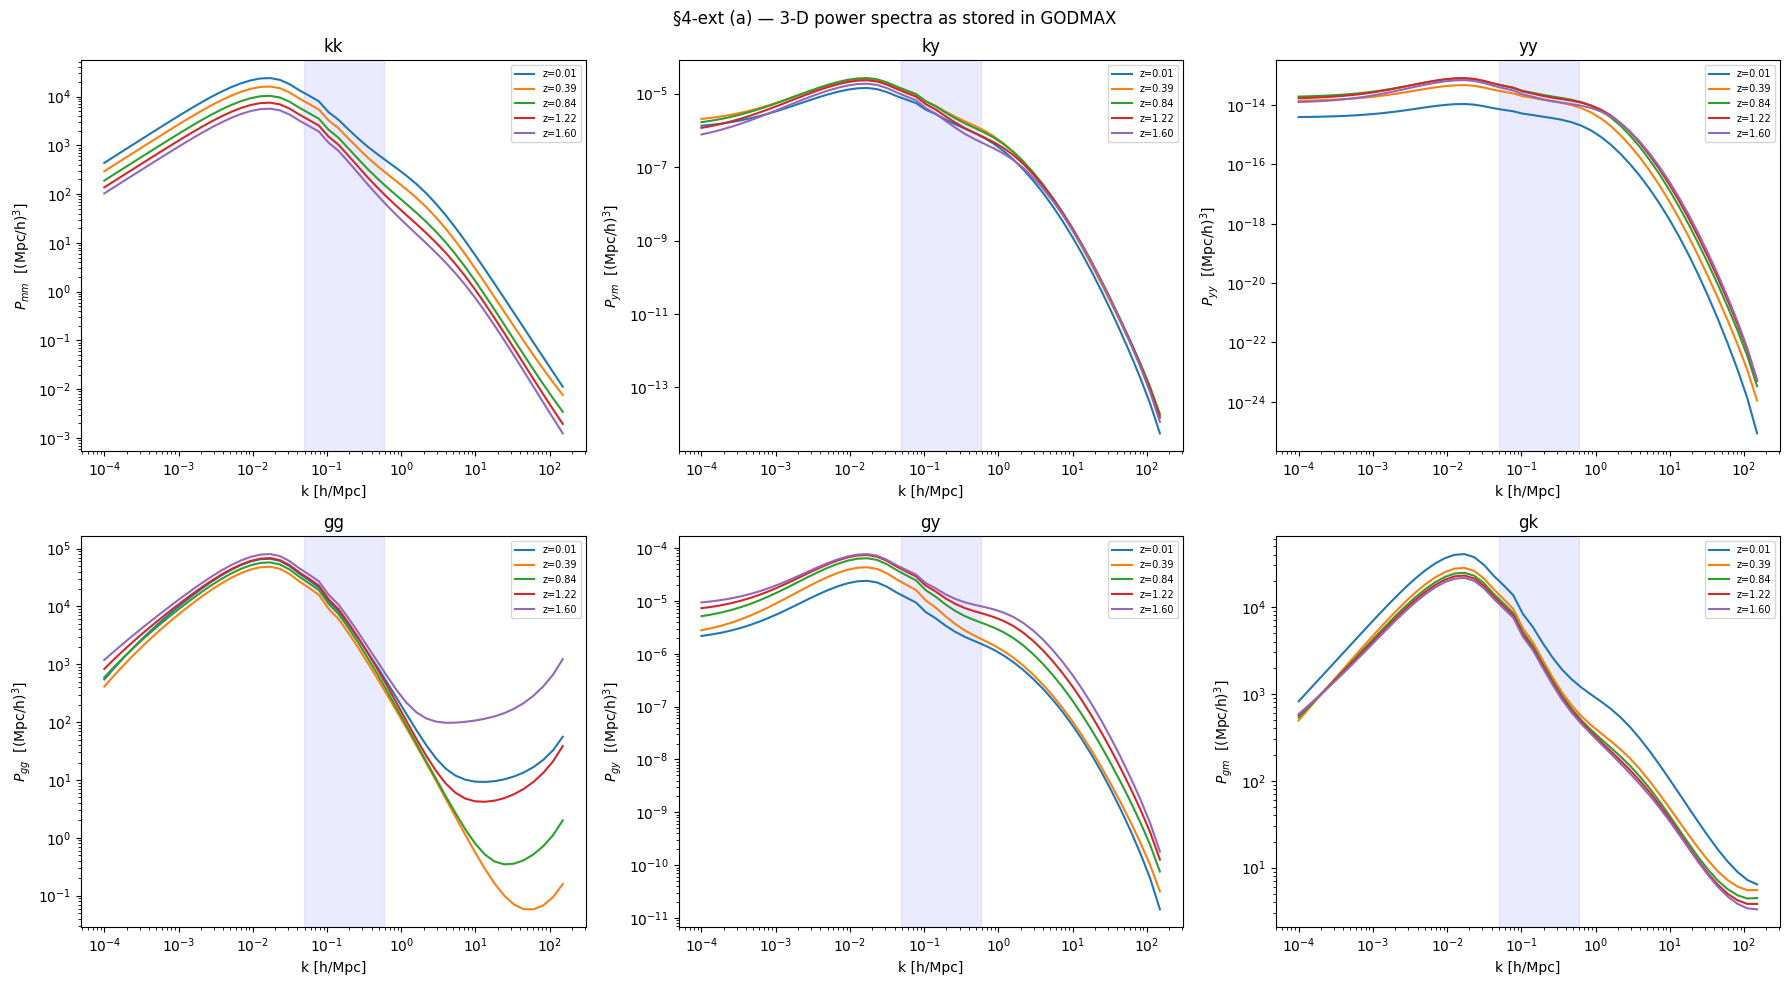

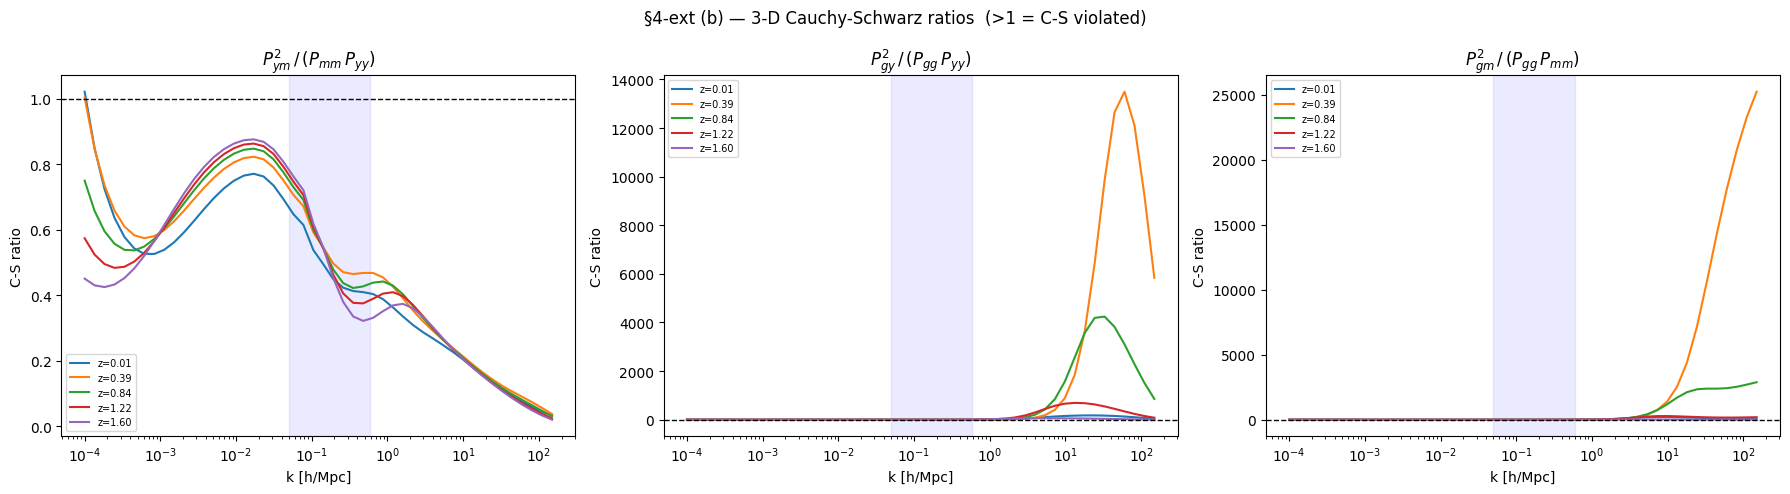

3-D C-S ratios in Limber band ell=[100,1200]:
pair    z       k_lo      k_hi      max ratio     flag
----------------------------------------------------------
ky-kkkk  0.01    3.3160    39.6100   0.2684        ok
ky-kkkk  0.39    0.0950    1.1343    0.5917        ok
ky-kkkk  0.84    0.0494    0.5906    0.7296        ok
ky-kkkk  1.22    0.0377    0.4501    0.7916        ok
ky-kkkk  1.60    0.0316    0.3774    0.8069        ok
gy-gggg  0.01    3.3160    39.6100   177.9792      VIOLATED
gy-gggg  0.39    0.0950    1.1343    2.4058        VIOLATED
gy-gggg  0.84    0.0494    0.5906    1.8106        VIOLATED
gy-gggg  1.22    0.0377    0.4501    2.1226        VIOLATED
gy-gggg  1.60    0.0316    0.3774    3.6139        VIOLATED
gk-gggg  0.01    3.3160    39.6100   209.8790      VIOLATED
gk-gggg  0.39    0.0950    1.1343    6.9297        VIOLATED
gk-gggg  0.84    0.0494    0.5906    3.1930        VIOLATED
gk-gggg  1.22    0.0377    0.4501    2.3603        VIOLATED
gk-gggg  1.60    0.0316    0.3

In [12]:
# ── Common grids ─────────────────────────────────────────────────────────────
kPk    = np.array(Cls_test.kPk_array)       # (nk,)
z_th   = np.array(Cls_test.z_array)          # (nz,)
nz_hm  = len(z_th)
z_sel  = np.unique([0, nz_hm//4, nz_hm//2, 3*nz_hm//4, nz_hm-1])
chi_arr = np.array(Cls_test.chi_array)       # (nz,)
jz_mid  = z_sel[len(z_sel)//2]

# ── Actual 3-D spectra as stored in GODMAX ───────────────────────────────────
Pk3d = {
    'kk': np.array(Cls_test.Pmm_tot_mat),      # (nk, nz)  P_mm used for C_kk
    'ky': np.array(Cls_test.Pym_tot_mat),      # (nk, nz)  P_ym used for C_ky
    'yy': np.array(Cls_test.Pyy_tot_kz_mat),  # (nk, nz)  P_yy used for C_yy
    'gg': np.array(Cls_test.Pgg_tot_mat),      # (nk, nz)  P_gg used for C_gg
    'gy': np.array(Cls_test.Pgy_tot_mat),      # (nk, nz)  P_gy used for C_gy
    'gk': np.array(Cls_test.Pgm_tot_mat),      # (nk, nz)  P_gm used for C_gk
}
ylabels = {
    'kk': r'$P_{mm}$  [(Mpc/h)$^3$]',
    'ky': r'$P_{ym}$  [(Mpc/h)$^3$]',
    'yy': r'$P_{yy}$  [(Mpc/h)$^3$]',
    'gg': r'$P_{gg}$  [(Mpc/h)$^3$]',
    'gy': r'$P_{gy}$  [(Mpc/h)$^3$]',
    'gk': r'$P_{gm}$  [(Mpc/h)$^3$]',
}

# ── Figure 1: actual Pk shapes ───────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 10))
fig1.suptitle('§4-ext (a) — 3-D power spectra as stored in GODMAX', fontsize=12)

for ax, probe in zip(axes1.ravel(), ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']):
    for jz in z_sel:
        ax.loglog(kPk, np.clip(Pk3d[probe][:, jz], 1e-40, None),
                  label=f'z={z_th[jz]:.2f}')
    # Limber band for ell=[100,1200] at jz_mid
    chi_z = chi_arr[jz_mid]
    ax.axvspan(100.5/max(chi_z, 1.), 1200.5/max(chi_z, 1.), alpha=0.08, color='blue')
    ax.set(xlabel='k [h/Mpc]', ylabel=ylabels[probe], title=probe)
    ax.legend(fontsize=7)

plt.tight_layout()
fig1.savefig(os.path.join(FIGDIR, 'pk3d_allprobes_shapes.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: 3-D C-S ratios ─────────────────────────────────────────────────
# r_ym = P_ym^2 / (P_mm * P_yy)  — uses the SAME spectra that enter C_ky, C_kk, C_yy
# r_gy = P_gy^2 / (P_gg * P_yy)
# r_gm = P_gm^2 / (P_gg * P_mm)
cs_pairs = [
    ('ky', 'kk', 'yy', r'$P_{ym}^2\,/\,(P_{mm}\,P_{yy})$'),
    ('gy', 'gg', 'yy', r'$P_{gy}^2\,/\,(P_{gg}\,P_{yy})$'),
    ('gk', 'gg', 'kk', r'$P_{gm}^2\,/\,(P_{gg}\,P_{mm})$'),
]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('§4-ext (b) — 3-D Cauchy-Schwarz ratios  (>1 = C-S violated)', fontsize=12)

for ax, (pxy, pxx, pyy, title) in zip(axes2, cs_pairs):
    for jz in z_sel:
        denom = np.clip(Pk3d[pxx][:, jz] * Pk3d[pyy][:, jz], 1e-60, None)
        ratio = Pk3d[pxy][:, jz]**2 / denom
        ax.semilogx(kPk, ratio, label=f'z={z_th[jz]:.2f}')
    chi_z = chi_arr[jz_mid]
    ax.axvspan(100.5/max(chi_z, 1.), 1200.5/max(chi_z, 1.), alpha=0.08, color='blue')
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set(xscale='log', xlabel='k [h/Mpc]', ylabel='C-S ratio', title=title)
    ax.legend(fontsize=7)

plt.tight_layout()
fig2.savefig(os.path.join(FIGDIR, 'pk3d_cs_ratios.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Console: max C-S ratio in the Limber band per probe pair ─────────────────
print('3-D C-S ratios in Limber band ell=[100,1200]:')
print(f'{"pair":<6}  {"z":<6}  {"k_lo":<8}  {"k_hi":<8}  {"max ratio":<12}  flag')
print('-' * 58)
for pxy, pxx, pyy, _ in cs_pairs:
    for jz in z_sel:
        k_lo = 100.5  / max(chi_arr[jz], 1.)
        k_hi = 1200.5 / max(chi_arr[jz], 1.)
        mask = (kPk >= k_lo) & (kPk <= k_hi)
        if not mask.any():
            continue
        denom = np.clip(Pk3d[pxx][mask, jz] * Pk3d[pyy][mask, jz], 1e-60, None)
        ratio = Pk3d[pxy][mask, jz]**2 / denom
        flag = 'VIOLATED' if ratio.max() > 1 else 'ok'
        print(f'{pxy+"-"+pxx+pxx:<6}  {z_th[jz]:<6.2f}  {k_lo:<8.4f}  {k_hi:<8.4f}  {ratio.max():<12.4f}  {flag}')


## §11 — Limber integral validation: manual vs GODMAX `Cl_*_mat`

Replicate `get_Cl_tot` exactly in numpy using `cached_power_spectra` (shape `(nell, nz_for_Cls)`)
and compare against the stored GODMAX arrays for all six probes: **gg, kk, ky, gy, gk, yy**.

Window-function prefactors match `compute_prefac` in `get_Cl_tot` (get_Cls.py line 301):

| probe code | prefactor |
|---|---|
| 0 — κ | `(1+m_b) Wk[b] / χ²` |
| 2 — g | `Wg[b] / (dχ/dz · χ²)` |
| 3 — y | `Wy / χ²` |

Agreement should be at machine-precision level (relative error < 1e-5);
any larger discrepancy signals a mismatch between the cached Pk arrays
and the Cl output matrices.


Probe      max |rel err|    mean |rel err|  note
-----------------------------------------------------------------
kk             8.234e-16         1.810e-16  ok
ky             6.013e-16         1.983e-16  ok
yy             4.584e-16         1.605e-16  ok
gg             7.028e-16         1.493e-16  ok
gy             6.143e-16         1.476e-16  ok
gk             6.687e-16         1.515e-16  ok


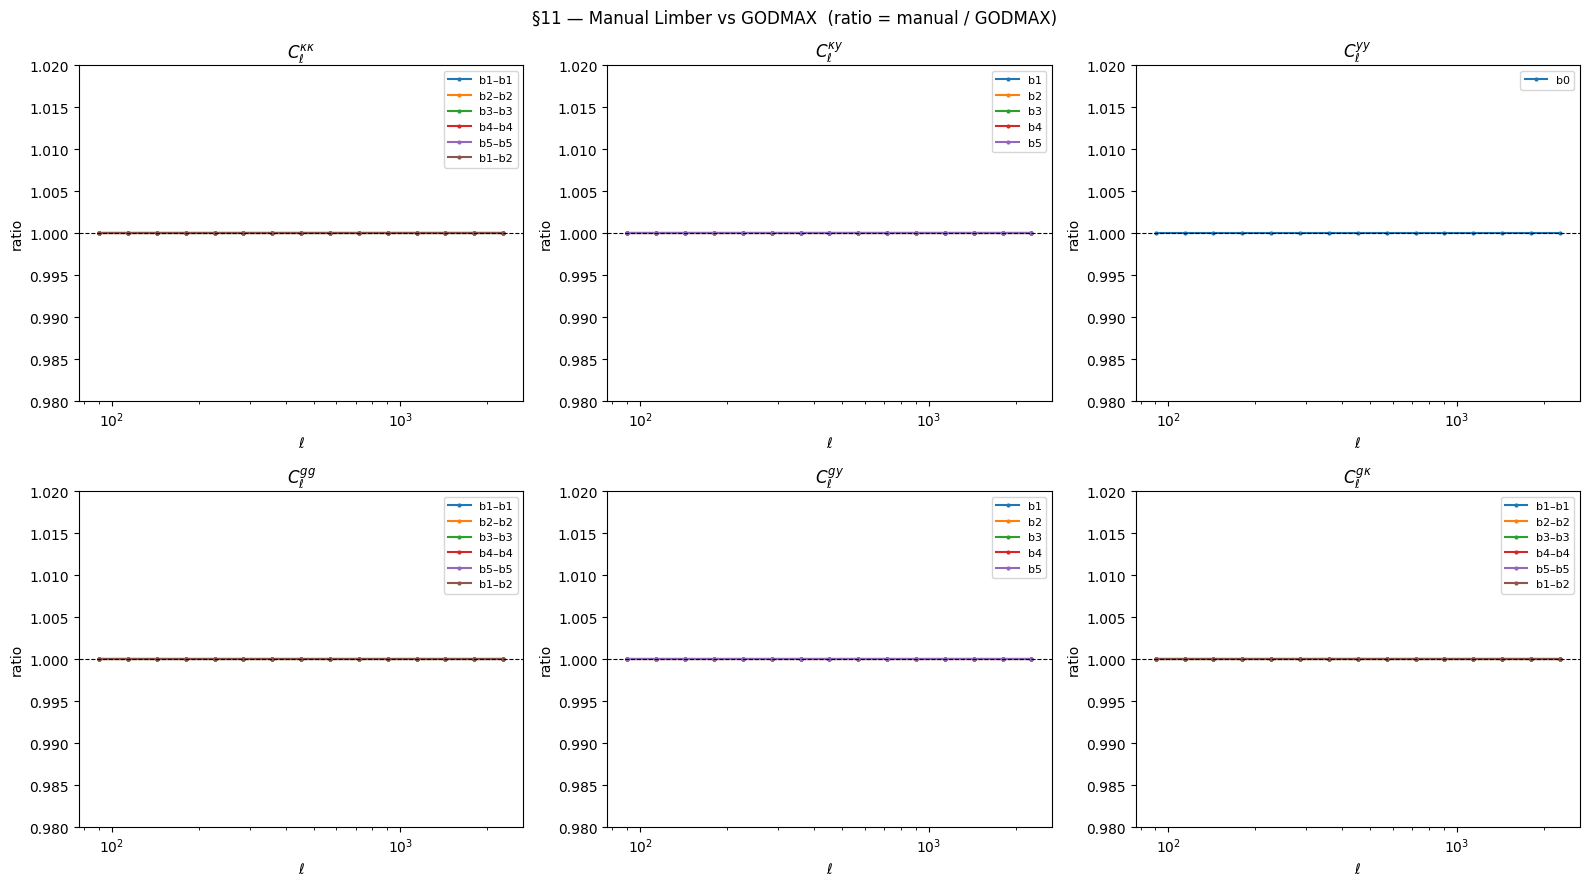

In [13]:
# ── Grid arrays on z_array_for_Cls ──────────────────────────────────────────
z_cls   = np.array(Cls_test.z_array_for_Cls)       # (nz_for_Cls,)
chi_cls = np.array(Cls_test.chi_array_for_Cls)      # (nz_for_Cls,)
dchi_dz = np.array(Cls_test.dchi_dz_array_for_Cls)  # (nz_for_Cls,)
ell_arr = np.array(Cls_test.ell_array)               # (nell,)

# ── Window functions (raw; prefactors applied below) ────────────────────────
Wk_all  = np.array(Cls_test.Wk_mat)                  # (nbins,     nz_for_Cls)
Wg_all  = np.array(Cls_test.Wg_mat)                  # (nbins_lens, nz_for_Cls)
Wy      = np.array(Cls_test.Wy_array)                 # (nz_for_Cls,)
mb      = np.array(Cls_test.mult_shear_bias_array)    # (nbins,) -- usually zeros

# ── Prefactors: compute_prefac in get_Cl_tot (get_Cls.py line 301) ──────────
def fk(jb): return (1.0 + mb[jb]) * Wk_all[jb] / chi_cls**2          # probe 0
def fg(jb): return Wg_all[jb] / (dchi_dz * chi_cls**2)                # probe 2
fy       = Wy / chi_cls**2                                             # probe 3

# ── Cached 3D power spectra on (nell, nz_for_Cls) ───────────────────────────
Pk = {
    'kk': np.array(Cls_test.cached_power_spectra[0, 0]),  # P_mm
    'ky': np.array(Cls_test.cached_power_spectra[0, 3]),  # P_ym
    'yy': np.array(Cls_test.cached_power_spectra[3, 3]),  # P_yy
    'gg': np.array(Cls_test.cached_power_spectra[2, 2]),  # P_gg
    'gy': np.array(Cls_test.cached_power_spectra[2, 3]),  # P_gy
    'gk': np.array(Cls_test.cached_power_spectra[2, 0]),  # P_gm
}

# ── Limber integrator: exact replica of get_Cl_tot's trapezoid ──────────────
def manual_cl(W1, W2, Pk_mat):
    """Cl[ell] = trapz( W1*W2*chi^2*dchi_dz*Pk, dz )  shape: (nell,)"""
    integrand = (W1 * W2 * chi_cls**2 * dchi_dz)[None, :] * Pk_mat  # (nell, nz)
    return np.trapezoid(integrand, z_cls, axis=1)

nbins      = Cls_test.nbins
nbins_lens = Cls_test.nbins_lens

# ── Compute manual Cls for every bin combo ───────────────────────────────────
man = {}
man['kk'] = np.array([[manual_cl(fk(b1), fk(b2), Pk['kk'])
                        for b2 in range(nbins)] for b1 in range(nbins)])          # (nb, nb, nell)
man['ky'] = np.array([manual_cl(fk(b), fy, Pk['ky']) for b in range(nbins)])      # (nb, nell)
man['yy'] = manual_cl(fy, fy, Pk['yy'])                                            # (nell,)
man['gg'] = np.array([[manual_cl(fg(b1), fg(b2), Pk['gg'])
                        for b2 in range(nbins_lens)] for b1 in range(nbins_lens)]) # (nb_l, nb_l, nell)
man['gy'] = np.array([manual_cl(fg(b), fy, Pk['gy']) for b in range(nbins_lens)]) # (nb_l, nell)
man['gk'] = np.array([[manual_cl(fg(b1), fk(b2), Pk['gk'])
                        for b2 in range(nbins)] for b1 in range(nbins_lens)])      # (nb_l, nb, nell)

# ── GODMAX reference arrays ──────────────────────────────────────────────────
# shapes: kk (nell,nb,nb), ky (nell,nb), yy (nell,)
#         gg (nell,nb_l,nb_l), gy (nell,nb_l), gk (nell,nb_l,nb)
ref = {
    'kk': np.array(Cls_test.Cl_kappa_kappa_tot_mat),  # (nell, nb, nb)
    'ky': np.array(Cls_test.Cl_kappa_y_tot_mat),       # (nell, nb)
    'yy': np.array(Cls_test.Cl_y_y_signal_mat),        # (nell,)
    'gg': np.array(Cls_test.Cl_gal_gal_tot_mat),       # (nell, nb_l, nb_l)
    'gy': np.array(Cls_test.Cl_gal_y_tot_mat),         # (nell, nb_l)
    'gk': np.array(Cls_test.Cl_gal_kappa_tot_mat),     # (nell, nb_l, nb)
}
# Transpose manual arrays to (nell, ...) for direct comparison
man_t = {
    'kk': man['kk'].transpose(2, 0, 1),   # (nell, nb, nb)
    'ky': man['ky'].T,                     # (nell, nb)
    'yy': man['yy'],                        # (nell,)
    'gg': man['gg'].transpose(2, 0, 1),    # (nell, nb_l, nb_l)
    'gy': man['gy'].T,                     # (nell, nb_l)
    'gk': man['gk'].transpose(2, 0, 1),   # (nell, nb_l, nb)
}

# ── Relative error diagnostic ────────────────────────────────────────────────
thresh = 1e-20   # ignore near-zero Cls
probe_labels = ['kk', 'ky', 'yy', 'gg', 'gy', 'gk']
probe_titles = {
    'kk': r'$C_\ell^{\kappa\kappa}$',
    'ky': r'$C_\ell^{\kappa y}$',
    'yy': r'$C_\ell^{yy}$',
    'gg': r'$C_\ell^{gg}$',
    'gy': r'$C_\ell^{gy}$',
    'gk': r'$C_\ell^{g\kappa}$',
}

print("{:<6}  {:>16}  {:>16}  {}".format("Probe", "max |rel err|", "mean |rel err|", "note"))
print('-' * 65)
for p in probe_labels:
    m, r = man_t[p].ravel(), ref[p].ravel()
    mask = np.abs(r) > thresh
    if mask.any():
        rel = np.abs(m[mask] - r[mask]) / np.abs(r[mask])
        note = 'WARN: >1e-4' if rel.max() > 1e-4 else 'ok'
        print(f'{p:<6}  {rel.max():>16.3e}  {rel.mean():>16.3e}  {note}')
    else:
        print(f"{p:<6}  N/A (all zero)")

# ── Comparison plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('§11 — Manual Limber vs GODMAX  (ratio = manual / GODMAX)', fontsize=12)

for ax, p in zip(axes.ravel(), probe_labels):
    m, r = man_t[p], ref[p]
    # Collapse bin axes: iterate over first extra dim if present
    if m.ndim == 1:
        combos = [(m, r, 'b0')]
    elif m.ndim == 2:
        combos = [(m[:, jb], r[:, jb], f'b{jb+1}') for jb in range(m.shape[1])]
    else:  # (nell, b1, b2) -- plot diagonal + (0,1) only
        combos = [(m[:, jb, jb], r[:, jb, jb], f'b{jb+1}–b{jb+1}')
                   for jb in range(m.shape[1])]
        if m.shape[1] > 1 and m.shape[2] > 0:
            combos.append((m[:, 0, 1], r[:, 0, 1], 'b1–b2'))

    for mc, rc, lbl in combos:
        mask = np.abs(rc) > thresh
        ratio = np.where(mask, mc / np.where(mask, rc, 1.0), np.nan)
        ax.plot(ell_arr, ratio, marker='.', ms=4, label=lbl)

    ax.axhline(1.0, ls='--', color='k', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('ratio')
    ax.set_title(probe_titles[p])
    ax.legend(fontsize=8)
    ax.set_ylim(0.98, 1.02)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'limber_validation_allprobes.png'), dpi=150, bbox_inches='tight')
plt.show()


## §12 — Angular Cauchy-Schwarz consistency

For a Gaussian random field, the signal power spectra must satisfy
$$C_{xy}^2(\ell) \leq C_{xx}(\ell)\,C_{yy}(\ell) \quad \forall\,\ell$$
for every pair of fields $(x, y)$.  Violation means the angular power spectra
are internally inconsistent and the Gaussian covariance matrix will not be PSD.

Checked here for the three cross-pairs that involve the tSZ field and
galaxy–lensing cross: $(\kappa y)$, $(gy)$, $(g\kappa)$, per tomographic bin.
All quantities are taken directly from `Cl_result_dict` — no modification applied.


κy  C-S ratios:
  b1: max r=0.3547  at ell=143.2  [ok]
  b2: max r=0.3345  at ell=180.3  [ok]
  b3: max r=0.3591  at ell=227.0  [ok]
  b4: max r=0.3755  at ell=359.7  [ok]
  b5: max r=0.3901  at ell=452.9  [ok]
gy  C-S ratios:
  b1: max r=7.9764  at ell=2269.7  [VIOLATED]
  b2: max r=4.3438  at ell=2269.7  [VIOLATED]
  b3: max r=4.3840  at ell=2269.7  [VIOLATED]
  b4: max r=3.0057  at ell=2269.7  [VIOLATED]
  b5: max r=2.4794  at ell=2269.7  [VIOLATED]
gκ  C-S ratios:
  g1-k1: max r=38.4158  at ell=2269.7  [VIOLATED]
  g1-k2: max r=47.2919  at ell=2269.7  [VIOLATED]
  g1-k3: max r=57.2025  at ell=2269.7  [VIOLATED]
  g1-k4: max r=57.8239  at ell=2269.7  [VIOLATED]
  g1-k5: max r=52.4269  at ell=2269.7  [VIOLATED]
  g2-k1: max r=3.9672  at ell=2269.7  [VIOLATED]
  g2-k2: max r=3.7609  at ell=2269.7  [VIOLATED]
  g2-k3: max r=11.8981  at ell=2269.7  [VIOLATED]
  g2-k4: max r=19.5129  at ell=2269.7  [VIOLATED]
  g2-k5: max r=20.8359  at ell=2269.7  [VIOLATED]
  g3-k1: max r=0.8393  at ell

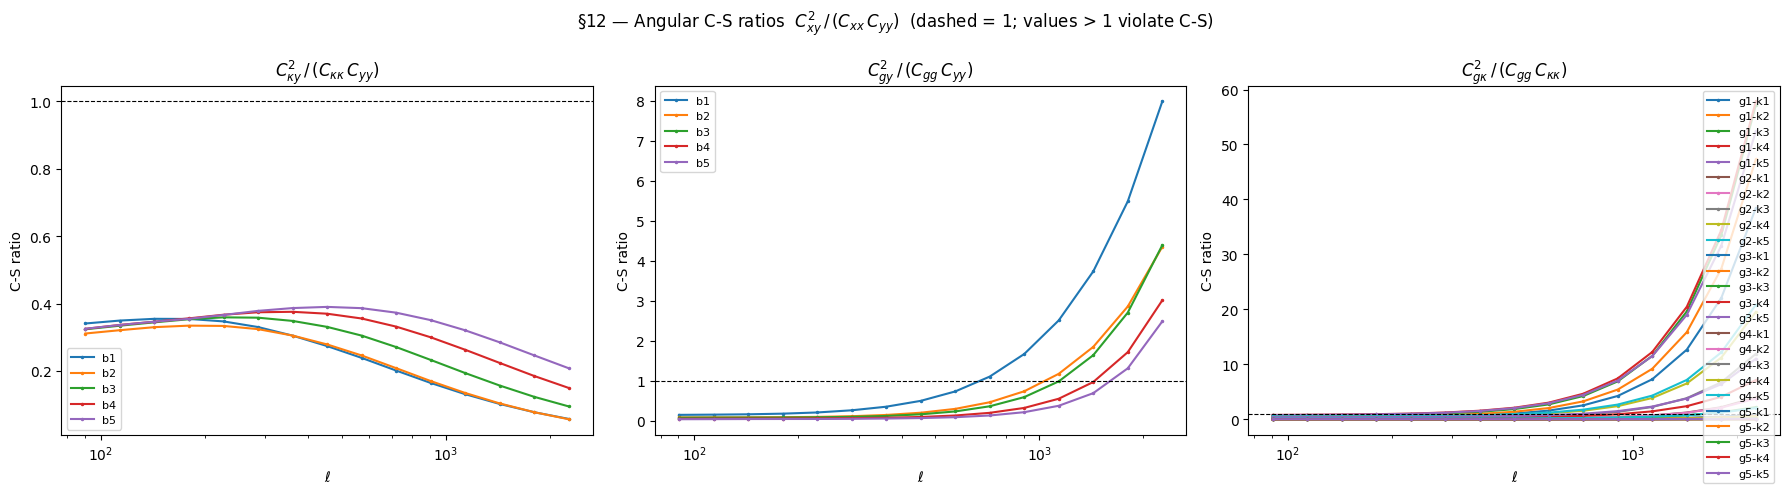

In [ ]:
# §11 must have run: ell_arr, ref, thresh already defined.
# ref['kk'] shape (nell, nb, nb); ref['ky'] (nell, nb); ref['yy'] (nell,)
# ref['gg'] (nell, nb_l, nb_l); ref['gy'] (nell, nb_l); ref['gk'] (nell, nb_l, nb)

Cyy = ref['yy']          # (nell,)
nbins      = ref['kk'].shape[1]
nbins_lens = ref['gg'].shape[1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    r'§12 — Angular C-S ratios  $C_{xy}^2\,/\,(C_{xx}\,C_{yy})$'
    '  (dashed = 1; values > 1 violate C-S)',
    fontsize=12
)

# ── (a) κy : C_ky^2 / (C_kk * C_yy) ─────────────────────────────────────────
ax = axes[0]
print('κy  C-S ratios:')
for jb in range(nbins):
    Cky = ref['ky'][:, jb]                   # (nell,)
    Ckk = ref['kk'][:, jb, jb]               # auto-bin
    denom = np.clip(Ckk * Cyy, 1e-60, None)
    ratio = Cky**2 / denom
    ax.plot(ell_arr, ratio, marker='.', ms=3, label=f'b{jb+1}')
    imax = np.nanargmax(ratio)
    flag = 'VIOLATED' if ratio[imax] > 1 else 'ok'
    print(f'  b{jb+1}: max r={ratio[imax]:.4f}  at ell={ell_arr[imax]:.1f}  [{flag}]')
ax.axhline(1.0, ls='--', color='k', lw=0.8)
ax.set(xscale='log', xlabel=r'$\ell$', ylabel='C-S ratio',
       title=r'$C_{\kappa y}^2\,/\,(C_{\kappa\kappa}\,C_{yy})$')
ax.legend(fontsize=8)

# ── (b) gy : C_gy^2 / (C_gg * C_yy) ─────────────────────────────────────────
ax = axes[1]
print('gy  C-S ratios:')
for jb in range(nbins_lens):
    Cgy = ref['gy'][:, jb]
    Cgg = ref['gg'][:, jb, jb]
    denom = np.clip(Cgg * Cyy, 1e-60, None)
    ratio = Cgy**2 / denom
    ax.plot(ell_arr, ratio, marker='.', ms=3, label=f'b{jb+1}')
    imax = np.nanargmax(ratio)
    flag = 'VIOLATED' if ratio[imax] > 1 else 'ok'
    print(f'  b{jb+1}: max r={ratio[imax]:.4f}  at ell={ell_arr[imax]:.1f}  [{flag}]')
ax.axhline(1.0, ls='--', color='k', lw=0.8)
ax.set(xscale='log', xlabel=r'$\ell$', ylabel='C-S ratio',
       title=r'$C_{gy}^2\,/\,(C_{gg}\,C_{yy})$')
ax.legend(fontsize=8)

# ── (c) gκ : C_gk^2 / (C_gg * C_kk) ─────────────────────────────────────────
ax = axes[2]
print('gκ  C-S ratios:')
for jbl in range(nbins_lens):
    for jbs in range(nbins):
        Cgk = ref['gk'][:, jbl, jbs]
        Cgg = ref['gg'][:, jbl, jbl]
        Ckk = ref['kk'][:, jbs, jbs]
        denom = np.clip(Cgg * Ckk, 1e-60, None)
        ratio = Cgk**2 / denom
        ax.plot(ell_arr, ratio, marker='.', ms=3, label=f'g{jbl+1}-k{jbs+1}')
        imax = np.nanargmax(ratio)
        flag = 'VIOLATED' if ratio[imax] > 1 else 'ok'
        print(f'  g{jbl+1}-k{jbs+1}: max r={ratio[imax]:.4f}  at ell={ell_arr[imax]:.1f}  [{flag}]')
ax.axhline(1.0, ls='--', color='k', lw=0.8)
ax.set(xscale='log', xlabel=r'$\ell$', ylabel='C-S ratio',
       title=r'$C_{g\kappa}^2\,/\,(C_{gg}\,C_{\kappa\kappa})$')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'angular_cs_ratios.png'), dpi=150, bbox_inches='tight')
plt.show()


## §13 — Effect of `Pmm_sup` on $C_\ell$: all probes

For each probe: ratio $C_\ell^{\rm with\,sup}\,/\,C_\ell^{\rm without\,sup}$,
evaluated using `cached_power_spectra` and `sup_limber` (the suppression factor
interpolated to Limber wavenumbers on the `z_array_for_Cls` grid).

Probes where `Pmm_sup` **is** applied in `poweradd` mode (`kk`, `gg`, `gk`):
ratio $< 1$ means the correction suppresses the Cl.  
Probes where it is **not** applied (`ky`, `gy`, `yy`):
ratio shows what the correction *would* do if applied — informative for
understanding the scale of the inconsistency between the two groups.


sup_limber range: [0.8461, 2.4955]


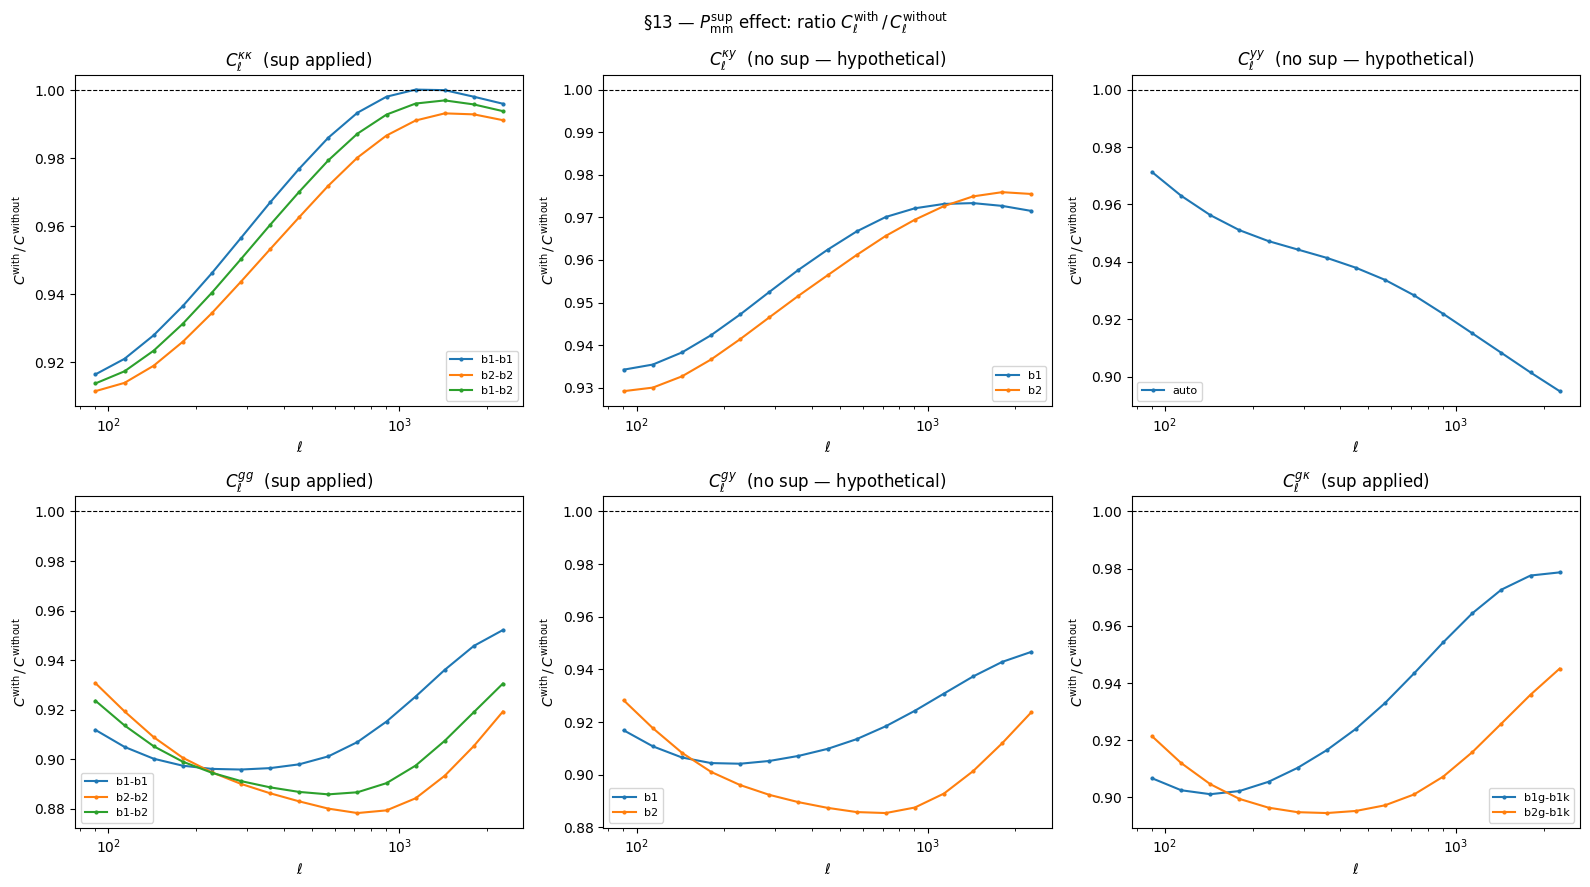


probe   ell[100,300]  ell[300,700]  ell[700,max]  sup in Pk?
--------------------------------------------------------------
kk            0.9377        0.9767        0.9977  YES
ky            0.9431        0.9622        0.9722  no
yy            0.9524        0.9377        0.9117  no
gg            0.8989        0.8985        0.9302  YES
gy            0.9062        0.9102        0.9334  no
gk            0.9043        0.9245        0.9652  YES


In [15]:
from scipy.interpolate import RegularGridInterpolator

# §11 must have run: z_cls, chi_cls, dchi_dz, ell_arr, Pk, manual_cl, fk, fg, fy
# §4-ext must have run: kPk, z_th, z_sel, chi_arr

# ── Build sup_limber[nell, nz_for_Cls] ───────────────────────────────────────
z_halo   = np.array(Cls_test.z_array)             # (nz,) halo model grid
sup_np   = np.array(Cls_test.Pmm_sup_tot_mat)     # (nk, nz)
z_cls_np = np.array(Cls_test.z_array_for_Cls)     # (nz_for_Cls,)

_sup_interp = RegularGridInterpolator(
    (np.log(kPk), z_halo),
    np.log(np.clip(sup_np, 1e-30, None)),
    method='linear', bounds_error=False, fill_value=None
)
sup_limber = np.zeros((len(ell_arr), len(z_cls_np)))
for jl, ell in enumerate(ell_arr):
    k_ells = (ell + 0.5) / np.clip(chi_cls, 1.0, None)
    pts    = np.column_stack([np.log(k_ells), z_cls_np])
    sup_limber[jl] = np.exp(_sup_interp(pts))
print(f'sup_limber range: [{sup_limber.min():.4f}, {sup_limber.max():.4f}]')

# ── Pk with / without sup ────────────────────────────────────────────────────
Pk_with = {
    'kk': Pk['kk'],               'gg': Pk['gg'],               'gk': Pk['gk'],
    'ky': Pk['ky'] * sup_limber,   'gy': Pk['gy'] * sup_limber,  'yy': Pk['yy'] * sup_limber,
}
Pk_without = {
    'kk': Pk['kk'] / sup_limber,   'gg': Pk['gg'] / sup_limber,  'gk': Pk['gk'] / sup_limber,
    'ky': Pk['ky'],                'gy': Pk['gy'],               'yy': Pk['yy'],
}

# ── Plot ─────────────────────────────────────────────────────────────────────
probe_configs = [
    ('kk', fk, fk, [(0, 0, 'b1-b1'), (1, 1, 'b2-b2'), (0, 1, 'b1-b2')]),
    ('ky', fk, fy, [(0, 0, 'b1'),    (1, 0, 'b2')]),
    ('yy', fy, fy, [(0, 0, '')]),
    ('gg', fg, fg, [(0, 0, 'b1-b1'), (1, 1, 'b2-b2'), (0, 1, 'b1-b2')]),
    ('gy', fg, fy, [(0, 0, 'b1'),    (1, 0, 'b2')]),
    ('gk', fg, fk, [(0, 0, 'b1g-b1k'), (1, 0, 'b2g-b1k')]),
]
has_sup = {'kk': True, 'gg': True, 'gk': True, 'ky': False, 'gy': False, 'yy': False}
probe_titles = {
    'kk': r'$C_\ell^{\kappa\kappa}$  (sup applied)',
    'ky': r'$C_\ell^{\kappa y}$  (no sup — hypothetical)',
    'yy': r'$C_\ell^{yy}$  (no sup — hypothetical)',
    'gg': r'$C_\ell^{gg}$  (sup applied)',
    'gy': r'$C_\ell^{gy}$  (no sup — hypothetical)',
    'gk': r'$C_\ell^{g\kappa}$  (sup applied)',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    r'§13 — $P_{\rm mm}^{\rm sup}$ effect: ratio $C_\ell^{\rm with}\,/\,C_\ell^{\rm without}$',
    fontsize=12
)
for ax, (probe, Wf1, Wf2, bin_combos) in zip(axes.ravel(), probe_configs):
    for b1, b2, lbl in bin_combos:
        W1 = Wf1(b1) if callable(Wf1) else Wf1
        W2 = Wf2(b2) if callable(Wf2) else Wf2
        cl_w  = manual_cl(W1, W2, Pk_with[probe])
        cl_wo = manual_cl(W1, W2, Pk_without[probe])
        ratio = np.where(np.abs(cl_wo) > 1e-30, cl_w / cl_wo, np.nan)
        ax.plot(ell_arr, ratio, marker='.', ms=4, label=lbl or 'auto')
    ax.axhline(1.0, ls='--', color='k', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$C^{\rm with}\,/\,C^{\rm without}$')
    ax.set_title(probe_titles[probe])
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'pmmsup_effect_allprobes.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("{:<6}  {:>12}  {:>12}  {:>12}  {}".format(
      'probe', 'ell[100,300]', 'ell[300,700]', 'ell[700,max]', 'sup in Pk?'))
print('-' * 62)
for probe, Wf1, Wf2, bin_combos in probe_configs:
    b1, b2, _ = bin_combos[0]
    W1 = Wf1(b1) if callable(Wf1) else Wf1
    W2 = Wf2(b2) if callable(Wf2) else Wf2
    cl_w  = manual_cl(W1, W2, Pk_with[probe])
    cl_wo = manual_cl(W1, W2, Pk_without[probe])
    ratio = np.where(np.abs(cl_wo) > 1e-30, cl_w / cl_wo, np.nan)
    def band(lo, hi):
        m = (ell_arr >= lo) & (ell_arr <= hi)
        v = ratio[m]
        return f'{np.nanmean(v):.4f}' if m.any() and not np.all(np.isnan(v)) else 'N/A'
    print("{:<6}  {:>12}  {:>12}  {:>12}  {}".format(
        probe, band(100, 300), band(300, 700), band(700, ell_arr.max()),
        'YES' if has_sup[probe] else 'no'))


## §14 — Gaussian covariance: Knox formula validation and Pmm_sup impact

GODMAX's `get_cov_G` implements the Knox formula:
$$\text{Cov}_G\!\left(C_\ell^{AB},\,C_\ell^{CD}\right) = \frac{\tilde C_\ell^{AC}\,\tilde C_\ell^{BD} + \tilde C_\ell^{AD}\,\tilde C_\ell^{BC}}{f_{\rm sky}\,(2\ell+1)\,\Delta\ell}$$
where $\tilde C$ denotes signal+noise.

**Goals**
1. **Validate** that GODMAX's `covG_dict` diagonal exactly matches the manual Knox formula.
2. **Probe by probe**: inspect $\sigma_G(\ell)$ for each auto-probe and key cross-probe pair.
3. **With vs without Pmm_sup**: `Pmm_sup` is applied to `P_gg` but not `P_gy`,
   so Knox variance $\tilde C_{gg}\,\tilde C_{yy} + \tilde C_{gy}^2$ mixes
   suppressed/unsuppressed Cls — compare against internally-consistent alternatives.

Requires §11 (`ell_arr`, `manual_cl`, `fk`, `fg`, `fy`, `ref`, `Pk`) and §13 (`Pk_with`, `Pk_without`, `sup_limber`).

In [16]:
# §14a — Instantiate get_cov and validate Knox formula
# §11 and §13 must have run.

from godmax.get_covs import get_cov

analysis_dict['stats_for_cov'] = ['yy', 'ky', 'kk', 'gy', 'gk', 'gg']

print('Instantiating get_cov (NG trispectra — may take ~1-2 min)...')
cov_test = get_cov(
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
    Cl_obj=Cls_test
)
print('Done.  covG_dict keys:', list(cov_test.covG_dict.keys()))

# ── Knox manual implementation ────────────────────────────────────────────────
ell_np = np.array(analysis_dict['l_array_survey'])
dl_np  = np.array(analysis_dict['dl_array_survey'])
Cl_res = cov_test.Cl_result_dict
fsky   = cov_test.fsky_dict

def knox_diag(C_AC, C_BD, C_AD, C_BC, fsky_val):
    return (np.array(C_AC) * np.array(C_BD) + np.array(C_AD) * np.array(C_BC)) / (
        fsky_val * (2 * ell_np + 1) * dl_np
    )

def cl_tot_res(probe, bkey):
    """Fetch tot+noise Cl from Cl_result_dict, trying reversed probe key if needed."""
    if probe in Cl_res and bkey in Cl_res[probe]:
        return np.array(Cl_res[probe][bkey]['tot_plus_noise_ellsurvey'])
    rprobe = probe[1] + probe[0]
    parts  = bkey.replace('bin_', '').split('_')
    rbkey  = 'bin_' + parts[1] + '_' + parts[0]
    return np.array(Cl_res[rprobe][rbkey]['tot_plus_noise_ellsurvey'])

# ── Validate: ratio covG_godmax_diag / knox_manual ───────────────────────────
# For auto-covariance Cov(C_AB_alpha, C_AB_alpha):
#   Knox = (C~_AA_alpha * C~_BB_alpha + C~_AB_alpha^2) / (fsky*(2l+1)*dl)
validate_cases = [
    # (covG_key,   bin_key,        C_AA probe/bkey,   C_BB probe/bkey,   C_AB probe/bkey, fsky_key)
    ('yy_yy', 'bin_0_0_0_0',  'yy','bin_0_0',  'yy','bin_0_0',  'yy','bin_0_0',  'yy'),
    ('ky_ky', 'bin_1_0_1_0',  'kk','bin_1_1',  'yy','bin_0_0',  'ky','bin_1_0',  'ky'),
    ('kk_kk', 'bin_1_1_1_1',  'kk','bin_1_1',  'kk','bin_1_1',  'kk','bin_1_1',  'kk'),
    ('gy_gy', 'bin_1_0_1_0',  'gg','bin_1_1',  'yy','bin_0_0',  'gy','bin_1_0',  'gy'),
    ('gy_gy', 'bin_2_0_2_0',  'gg','bin_2_2',  'yy','bin_0_0',  'gy','bin_2_0',  'gy'),
    ('gk_gk', 'bin_1_1_1_1',  'gg','bin_1_1',  'kk','bin_1_1',  'gk','bin_1_1',  'gk'),
    ('gg_gg', 'bin_1_1_1_1',  'gg','bin_1_1',  'gg','bin_1_1',  'gg','bin_1_1',  'gg'),
]

print(f"\n{'Case':<28}  {'min ratio':>10}  {'max ratio':>10}  {'mean':>10}")
print('-' * 64)
for (pk, bk, Ap, Ab, Bp, Bb, ABp, ABb, fk_key) in validate_cases:
    if pk not in cov_test.covG_dict or bk not in cov_test.covG_dict[pk]:
        print(f"  {pk}/{bk}: not found, skipping")
        continue
    godmax_diag = np.diag(np.array(cov_test.covG_dict[pk][bk]))
    C_AA = cl_tot_res(Ap, Ab)
    C_BB = cl_tot_res(Bp, Bb)
    C_AB = cl_tot_res(ABp, ABb)
    knox  = knox_diag(C_AA, C_BB, C_AB, C_AB, fsky[fk_key])
    ratio = np.where(np.abs(knox) > 1e-60, godmax_diag / knox, np.nan)
    label = f'{pk}/{bk}'
    print(f"  {label:<28}  {np.nanmin(ratio):>10.6f}  {np.nanmax(ratio):>10.6f}  {np.nanmean(ratio):>10.6f}")
print('\nAll should be 1.0 — confirms GODMAX implements Knox exactly.')


Instantiating get_cov (NG trispectra — may take ~1-2 min)...
Done.  covG_dict keys: ['yy_yy', 'yy_ky', 'yy_kk', 'yy_gy', 'yy_gk', 'yy_gg', 'ky_ky', 'ky_kk', 'ky_gy', 'ky_gk', 'ky_gg', 'kk_kk', 'kk_gy', 'kk_gk', 'kk_gg', 'gy_gy', 'gy_gk', 'gy_gg', 'gk_gk', 'gk_gg', 'gg_gg']

Case                           min ratio   max ratio        mean
----------------------------------------------------------------
  yy_yy/bin_0_0_0_0               1.000000    1.000000    1.000000
  ky_ky/bin_1_0_1_0               1.000000    1.000000    1.000000
  kk_kk/bin_1_1_1_1               1.357983    1.987096    1.782356
  gy_gy/bin_1_0_1_0               1.000000    1.000000    1.000000
  gy_gy/bin_2_0_2_0               1.000000    1.000000    1.000000
  gk_gk/bin_1_1_1_1               1.000000    1.000000    1.000000
  gg_gg/bin_1_1_1_1               1.000000    1.000000    1.000000

All should be 1.0 — confirms GODMAX implements Knox exactly.


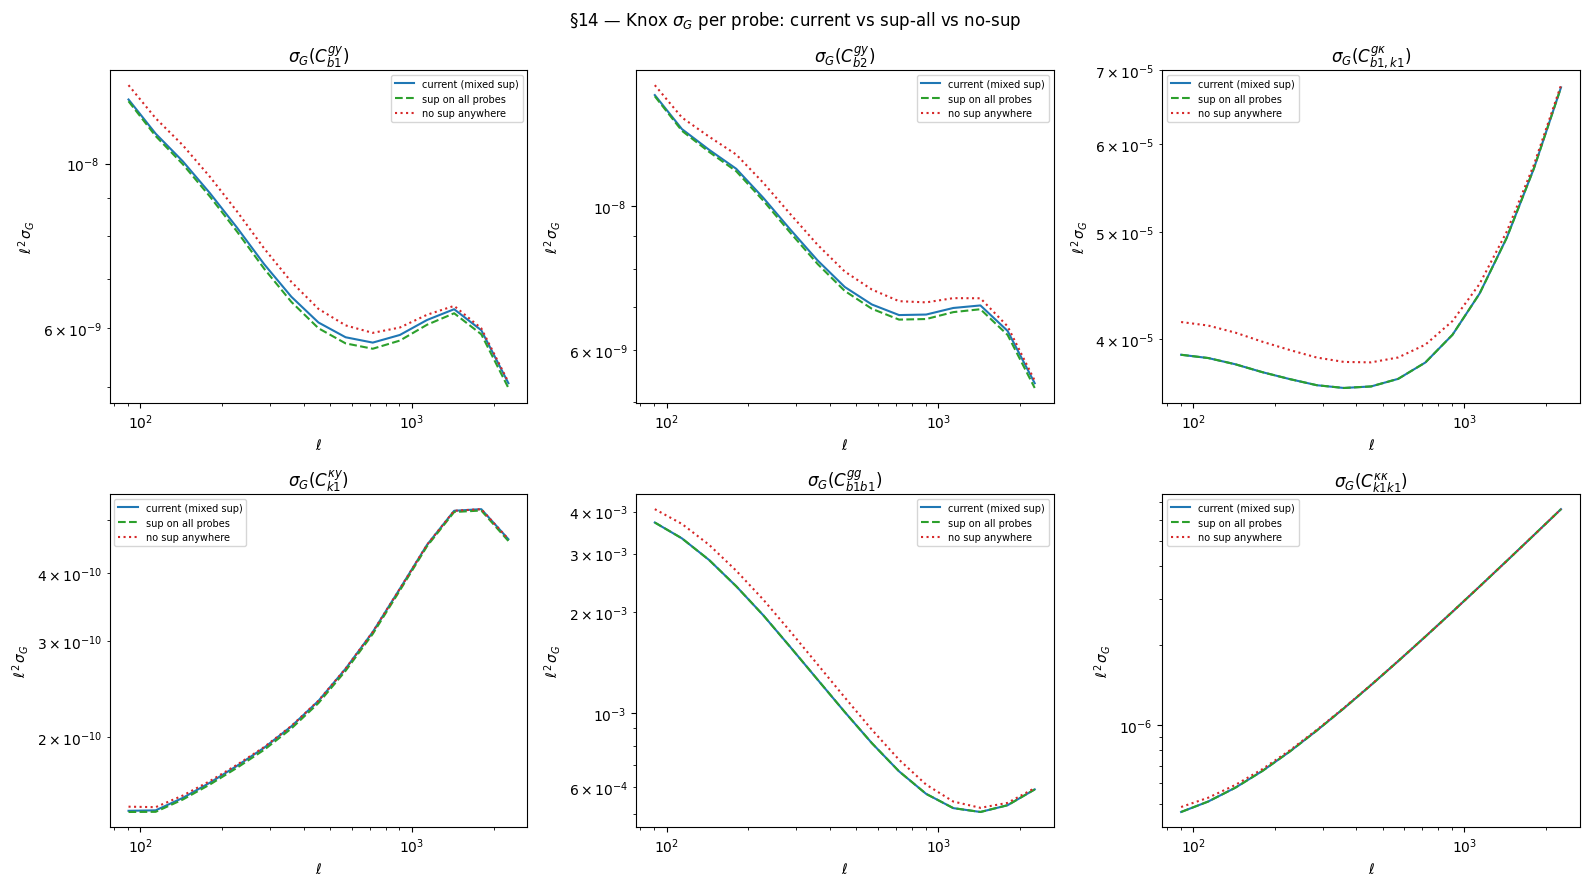

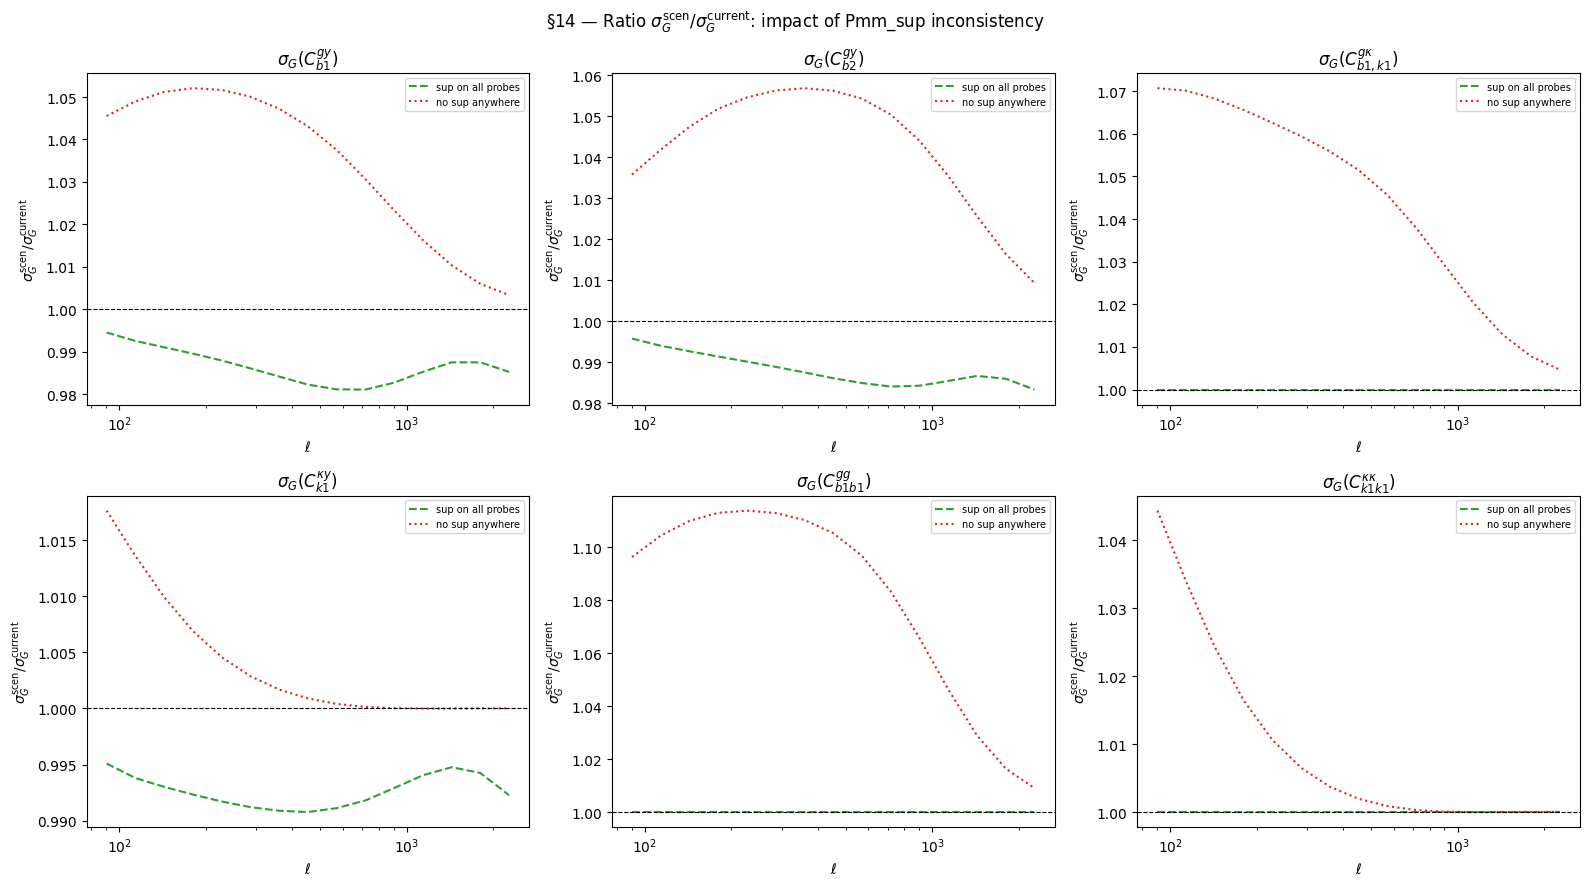

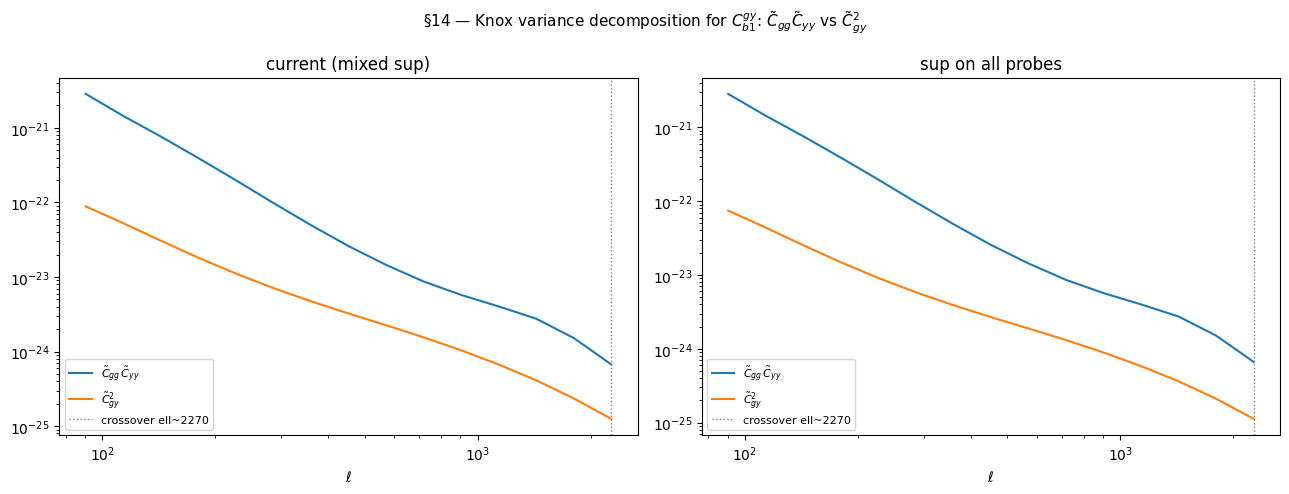

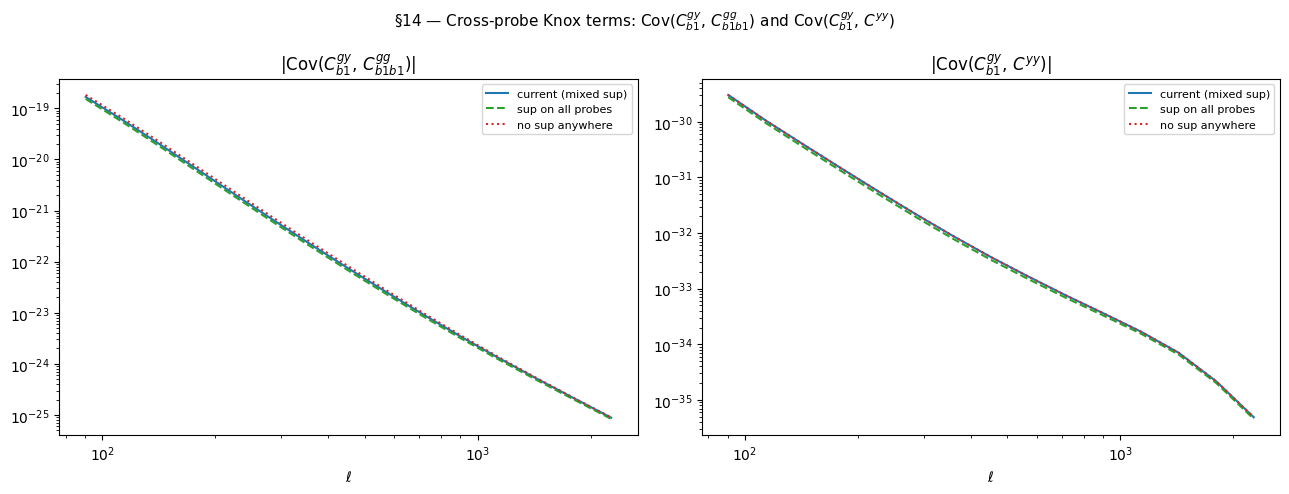


Fractional change in sigma_G (mean over ell > 500):
Probe                        sup-all/current   no-sup/current
------------------------------------------------------------
  $\sigma_G(C^{gy}_{b1})$               0.9844           1.0182
  $\sigma_G(C^{gy}_{b2})$               0.9849           1.0337
  $\sigma_G(C^{g\kappa}_{b1,k1})$            1.0000           1.0226
  $\sigma_G(C^{\kappa y}_{k1})$            0.9930           1.0001
  $\sigma_G(C^{gg}_{b1b1})$             1.0000           1.0495
  $\sigma_G(C^{\kappa\kappa}_{k1k1})$            1.0000           1.0002


In [17]:
# §14b — Knox sigma_G: current (mixed sup) vs sup-all vs no-sup
# Uses Pk_with, Pk_without, N_yy from §13; fk, fg, fy, manual_cl from §11.

nbins_l = nbins_lens
nbins_s = nbins_source

nbar_rad2   = np.array(analysis_dict['nbar_lens_bins']) * (180 * 60 / np.pi)**2
sig_eps_arr = np.array(analysis_dict['sigma_epsilon_SN_bins'])[:nbins_s]
neff_arr    = np.array(analysis_dict['neff_arcmin2_SN_bins'])[:nbins_s] * (180 * 60 / np.pi)**2
N_gg_bins   = 1.0 / nbar_rad2
N_kk_bins   = sig_eps_arr**2 / neff_arr
N_yy_arr    = np.array(Cl_res['yy']['bin_0_0']['noise_ellsurvey'])

# ── theory Cl from a given Pk dict ───────────────────────────────────────────
def th(probe, b1, b2, pk_dict):
    W1 = (fk(b1) if probe[0] == 'k' else (fg(b1) if probe[0] == 'g' else fy))
    W2 = (fk(b2) if probe[1] == 'k' else (fg(b2) if probe[1] == 'g' else fy))
    return manual_cl(W1, W2, pk_dict[probe])

def th_tot(probe, b1, b2, pk_dict):
    """Theory + noise (noise is scenario-independent)."""
    cl = th(probe, b1, b2, pk_dict)
    if probe == 'gg' and b1 == b2:
        cl = cl + N_gg_bins[b1]
    elif probe == 'kk' and b1 == b2:
        cl = cl + N_kk_bins[b1]
    elif probe == 'yy':
        cl = cl + N_yy_arr
    return cl

def sigma_G_probe(probe, bg, bk, pk_dict):
    """
    Knox sigma_G for auto-covariance of C_probe[bg, bk]:
      probe='gy': bg=galaxy bin, bk ignored (y has no tomo bin)
      probe='gk': bg=galaxy bin, bk=kappa bin
      probe='ky': bk=kappa bin, bg ignored
      probe='gg'/'kk'/'yy': diagonal auto-bin
    """
    A, B = probe[0], probe[1]

    if A == 'g':
        C_AA = th_tot('gg', bg, bg, pk_dict)
    elif A == 'k':
        C_AA = th_tot('kk', bk, bk, pk_dict)
    else:
        C_AA = th_tot('yy', 0, 0, pk_dict)

    if B == 'g':
        C_BB = th_tot('gg', bg, bg, pk_dict)
    elif B == 'k':
        C_BB = th_tot('kk', bk, bk, pk_dict)
    else:
        C_BB = th_tot('yy', 0, 0, pk_dict)

    C_AB = th(probe, bg, bk, pk_dict)   # no noise for cross-spectrum
    return np.sqrt(knox_diag(C_AA, C_BB, C_AB, C_AB, fsky[probe]))

# ── Scenarios ─────────────────────────────────────────────────────────────────
scenarios = {
    'current (mixed sup)': Pk,
    'sup on all probes':   Pk_with,
    'no sup anywhere':     Pk_without,
}
colors = {'current (mixed sup)': 'C0', 'sup on all probes': 'C2', 'no sup anywhere': 'C3'}
ls_map  = {'current (mixed sup)': '-',  'sup on all probes': '--', 'no sup anywhere': ':'}

# Probe cases: (probe, galaxy-bin, kappa-bin, axis title)
probe_cases = [
    ('gy',  0, 0, r'$\sigma_G(C^{gy}_{b1})$'),
    ('gy',  1, 0, r'$\sigma_G(C^{gy}_{b2})$'),
    ('gk',  0, 0, r'$\sigma_G(C^{g\kappa}_{b1,k1})$'),
    ('ky',  0, 0, r'$\sigma_G(C^{\kappa y}_{k1})$'),
    ('gg',  0, 0, r'$\sigma_G(C^{gg}_{b1b1})$'),
    ('kk',  0, 0, r'$\sigma_G(C^{\kappa\kappa}_{k1k1})$'),
]

# ── Figure 1: sigma_G per scenario ───────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 3, figsize=(16, 9))
fig1.suptitle(r'§14 — Knox $\sigma_G$ per probe: current vs sup-all vs no-sup', fontsize=12)
for ax, (probe, bg, bk, title) in zip(axes1.ravel(), probe_cases):
    for scen, pk_dict in scenarios.items():
        sg = sigma_G_probe(probe, bg, bk, pk_dict)
        ax.plot(ell_arr, ell_arr**2 * sg, label=scen,
                color=colors[scen], ls=ls_map[scen], lw=1.5)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$\ell^2\,\sigma_G$')
    ax.set_title(title); ax.legend(fontsize=7)
plt.tight_layout()
fig1.savefig(os.path.join(FIGDIR, 'knox_sigmaG_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: ratio sigma_G / sigma_G_current ────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))
fig2.suptitle(r'§14 — Ratio $\sigma_G^{\rm scen} / \sigma_G^{\rm current}$: '
              r'impact of Pmm_sup inconsistency', fontsize=12)
for ax, (probe, bg, bk, title) in zip(axes2.ravel(), probe_cases):
    sg_cur = sigma_G_probe(probe, bg, bk, Pk)
    for scen, pk_dict in list(scenarios.items())[1:]:
        sg = sigma_G_probe(probe, bg, bk, pk_dict)
        ratio = np.where(sg_cur > 1e-60, sg / sg_cur, np.nan)
        ax.plot(ell_arr, ratio, label=scen, color=colors[scen], ls=ls_map[scen], lw=1.5)
    ax.axhline(1.0, ls='--', color='k', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$\sigma_G^{\rm scen} / \sigma_G^{\rm current}$')
    ax.set_title(title); ax.legend(fontsize=7)
plt.tight_layout()
fig2.savefig(os.path.join(FIGDIR, 'knox_sigmaG_ratio_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Knox term decomposition for gy_b1 ──────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle(r'§14 — Knox variance decomposition for $C^{gy}_{b1}$: '
              r'$\tilde C_{gg}\tilde C_{yy}$ vs $\tilde C_{gy}^2$', fontsize=11)
bg = 0
for ax, (scen, pk_dict) in zip(axes3, [
        ('current (mixed sup)', Pk), ('sup on all probes', Pk_with)]):
    C_gg = th_tot('gg', bg, bg, pk_dict)
    C_yy = th_tot('yy', 0,  0,  pk_dict)
    C_gy = th('gy', bg, 0, pk_dict)
    term1 = C_gg * C_yy
    term2 = C_gy**2
    crossover_idx = np.argmin(np.abs(term1 - term2))
    ax.plot(ell_arr, term1, label=r'$\tilde C_{gg}\,\tilde C_{yy}$', color='C0', lw=1.5)
    ax.plot(ell_arr, term2, label=r'$\tilde C_{gy}^2$',                color='C1', lw=1.5)
    ax.axvline(ell_arr[crossover_idx], ls=':', color='gray', lw=1,
               label=f'crossover ell~{ell_arr[crossover_idx]:.0f}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_title(scen); ax.legend(fontsize=8)
plt.tight_layout()
fig3.savefig(os.path.join(FIGDIR, 'knox_gy_term_decomp.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4: cross-probe Knox terms Cov(gy_b1, gg_b1b1) and Cov(gy_b1, yy) ─
fig4, axes4 = plt.subplots(1, 2, figsize=(13, 5))
fig4.suptitle(r'§14 — Cross-probe Knox terms: '
              r'$\text{Cov}(C^{gy}_{b1},\,C^{gg}_{b1b1})$ and '
              r'$\text{Cov}(C^{gy}_{b1},\,C^{yy})$', fontsize=11)
bg = 0
for scen, pk_dict in scenarios.items():
    C_gg = th_tot('gg', bg, bg, pk_dict)
    C_yy = th_tot('yy', 0,  0,  pk_dict)
    C_gy = th('gy', bg, 0, pk_dict)
    # Cov(gy_b1, gg_b1b1) = 2*C~_gg*C~_gy / (sqrt(f_gy*f_gg)*(2l+1)*dl)
    fsky_cross = np.sqrt(fsky['gy'] * fsky['gg'])
    cov_gy_gg = 2 * C_gg * C_gy / (fsky_cross * (2*ell_arr + 1) * dl_np)
    # Cov(gy_b1, yy) = 2*C~_gy*C~_yy / (sqrt(f_gy*f_yy)*(2l+1)*dl)
    fsky_cross2 = np.sqrt(fsky['gy'] * fsky['yy'])
    cov_gy_yy = 2 * C_gy * C_yy / (fsky_cross2 * (2*ell_arr + 1) * dl_np)
    axes4[0].plot(ell_arr, np.abs(cov_gy_gg), label=scen,
                  color=colors[scen], ls=ls_map[scen], lw=1.5)
    axes4[1].plot(ell_arr, np.abs(cov_gy_yy), label=scen,
                  color=colors[scen], ls=ls_map[scen], lw=1.5)

for ax, title in zip(axes4, [r'$|\text{Cov}(C^{gy}_{b1},\,C^{gg}_{b1b1})|$',
                               r'$|\text{Cov}(C^{gy}_{b1},\,C^{yy})|$']):
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$'); ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout()
fig4.savefig(os.path.join(FIGDIR, 'knox_cross_probe_cov.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nFractional change in sigma_G (mean over ell > 500):')
print(f"{'Probe':<26}  {'sup-all/current':>16}  {'no-sup/current':>15}")
print('-' * 60)
ell_mask = ell_arr > 500
for probe, bg, bk, title in probe_cases:
    sg_cur  = sigma_G_probe(probe, bg, bk, Pk)
    sg_all  = sigma_G_probe(probe, bg, bk, Pk_with)
    sg_none = sigma_G_probe(probe, bg, bk, Pk_without)
    r_all  = np.nanmean(np.where(sg_cur > 1e-60, sg_all  / sg_cur, np.nan)[ell_mask])
    r_none = np.nanmean(np.where(sg_cur > 1e-60, sg_none / sg_cur, np.nan)[ell_mask])
    print(f"  {title:<26}  {r_all:>16.4f}  {r_none:>15.4f}")


Computing eigenvalues: current (mixed sup) ... done.  Knox neg eig count: 0,  field neg eig count: 0
Computing eigenvalues: sup on all probes ... done.  Knox neg eig count: 0,  field neg eig count: 0
Computing eigenvalues: no sup anywhere ... done.  Knox neg eig count: 0,  field neg eig count: 0


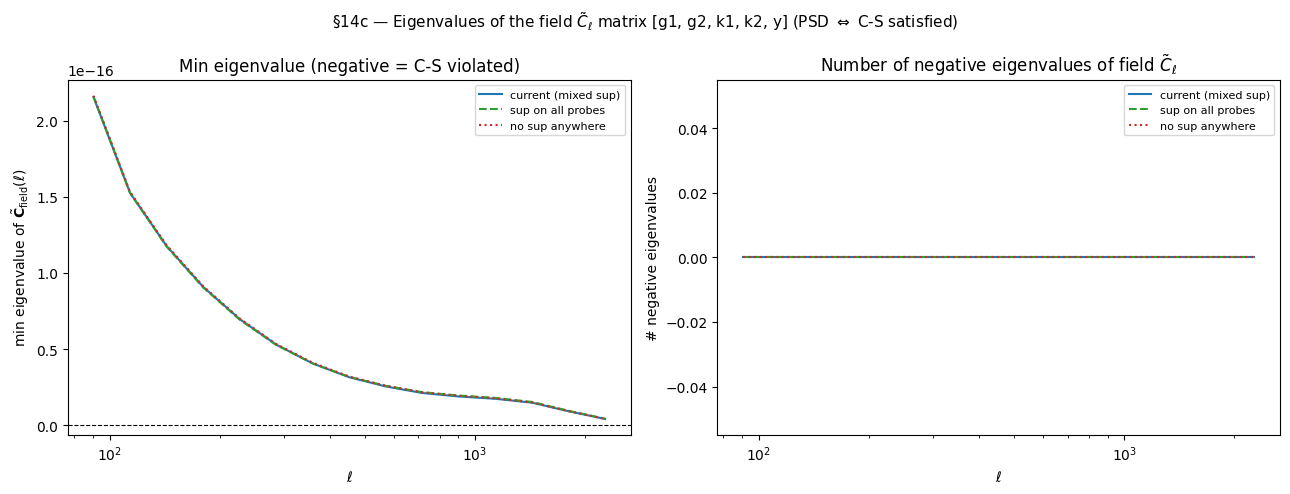

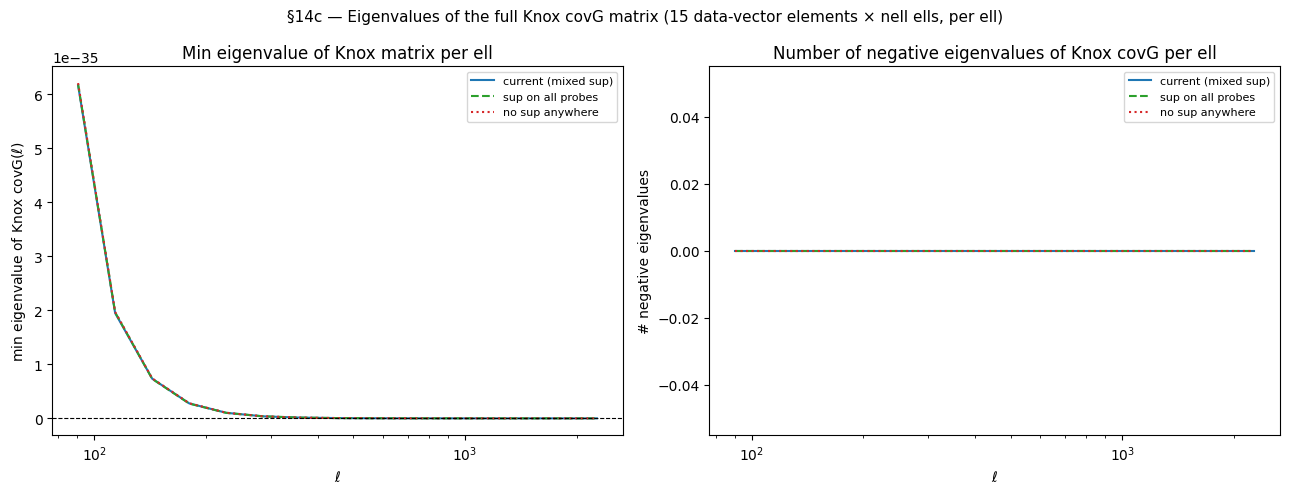


Scenario                    field neg ells   field min eig  knox neg ells  knox min eig
-------------------------------------------------------------------------------------
  current (mixed sup)                      0       4.013e-18              0     3.408e-41
  sup on all probes                        0       4.175e-18              0     3.688e-41
  no sup anywhere                          0       4.043e-18              0     3.460e-41


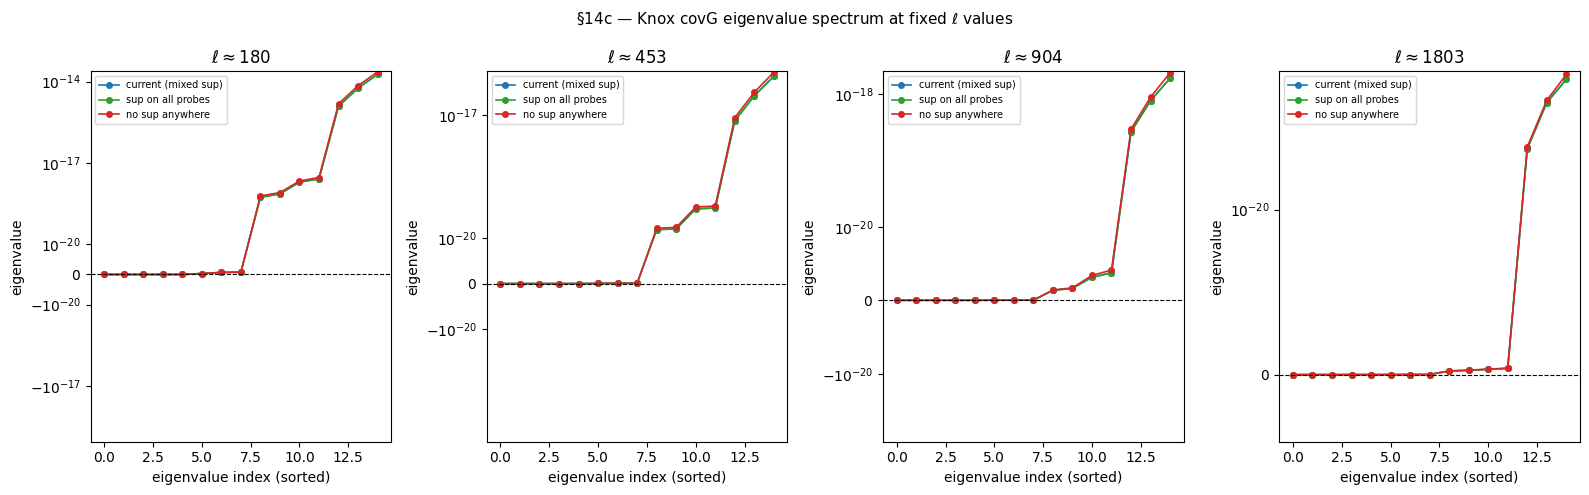

In [18]:
# §14c — Eigenvalue check of the Gaussian covariance under each Pmm_sup scenario
#
# Strategy:
#   (1) Build the FIELD Cl matrix at each ell: P[i,j,l] = C~(field_i, field_j)[l]
#       where field-bins = [g1, g2, k1, k2, y]. PSD <=> C-S satisfied for all probes.
#   (2) Build the full Knox covG matrix at each ell over all data-vector elements.
#       PSD <=> the covariance is physically valid.
#   Both tests run for 3 Pmm_sup scenarios: current, sup-all, no-sup.

nell = len(ell_arr)

# ── Field-bin definitions ─────────────────────────────────────────────────────
# field_bins: (field letter, bin index)   [y has only bin 0]
field_bins = [('g', 0), ('g', 1), ('k', 0), ('k', 1), ('y', 0)]
n_fields   = len(field_bins)

# ── Data-vector probe-bin combinations ───────────────────────────────────────
# Each entry: (probe_key, idx_into_field_bins for A, idx_into_field_bins for B)
data_combos = [
    ('yy', 4, 4),   # y × y
    ('ky', 2, 4),   # k1 × y
    ('ky', 3, 4),   # k2 × y
    ('kk', 2, 2),   # k1k1
    ('kk', 3, 3),   # k2k2
    ('kk', 2, 3),   # k1k2
    ('gy', 0, 4),   # g1 × y
    ('gy', 1, 4),   # g2 × y
    ('gk', 0, 2),   # g1k1
    ('gk', 0, 3),   # g1k2
    ('gk', 1, 2),   # g2k1
    ('gk', 1, 3),   # g2k2
    ('gg', 0, 0),   # g1g1
    ('gg', 1, 1),   # g2g2
    ('gg', 0, 1),   # g1g2
]
n_dv = len(data_combos)

dv_labels = [
    'yy', 'ky_k1','ky_k2',
    'kk_11','kk_22','kk_12',
    'gy_g1','gy_g2',
    'gk_g1k1','gk_g1k2','gk_g2k1','gk_g2k2',
    'gg_11','gg_22','gg_12',
]

# ── Cross-Cl helper (signal + noise for auto-spectra) ────────────────────────
def cl_cross(X, bX, Y, bY, pk_dict):
    """C~(field X bin bX, field Y bin bY) including shot/shape/yy noise."""
    if X == 'y': bX = 0
    if Y == 'y': bY = 0
    key  = X + Y if (X + Y) in pk_dict else Y + X
    WX   = fk(bX) if X == 'k' else (fg(bX) if X == 'g' else fy)
    WY   = fk(bY) if Y == 'k' else (fg(bY) if Y == 'g' else fy)
    # ordered window functions to match probe key
    if key == X + Y:
        cl = manual_cl(WX, WY, pk_dict[key])
    else:
        cl = manual_cl(WY, WX, pk_dict[key])
    # add noise on auto-spectra diagonal
    if X == Y == 'g' and bX == bY:
        cl = cl + N_gg_bins[bX]
    elif X == Y == 'k' and bX == bY:
        cl = cl + N_kk_bins[bX]
    elif X == Y == 'y':
        cl = cl + N_yy_arr
    return cl   # shape (nell,)

# ── Run eigenvalue analysis for each scenario ─────────────────────────────────
results = {}
for scen, pk_dict in scenarios.items():
    print(f'Computing eigenvalues: {scen} ...', end=' ', flush=True)

    # Pre-compute all pairwise Cls (nell,)
    Cl_fb = np.zeros((n_fields, n_fields, nell))
    for i, (Xi, bi) in enumerate(field_bins):
        for j, (Xj, bj) in enumerate(field_bins):
            Cl_fb[i, j] = cl_cross(Xi, bi, Xj, bj, pk_dict)

    # (1) Field Cl matrix eigenvalues per ell
    min_eig_field  = np.zeros(nell)
    n_neg_field    = np.zeros(nell, dtype=int)
    for l in range(nell):
        ev = np.linalg.eigvalsh(Cl_fb[:, :, l])
        min_eig_field[l] = ev.min()
        n_neg_field[l]   = np.sum(ev < 0)

    # (2) Knox covG matrix eigenvalues per ell
    min_eig_knox = np.zeros(nell)
    n_neg_knox   = np.zeros(nell, dtype=int)
    for l in range(nell):
        M = np.zeros((n_dv, n_dv))
        for i, (pi, fA, fB) in enumerate(data_combos):
            fs_i = fsky[pi]
            for j, (pj, fC, fD) in enumerate(data_combos):
                fs_j   = fsky[pj]
                fsky_ij = np.sqrt(fs_i * fs_j)
                C_AC = Cl_fb[fA, fC, l]
                C_BD = Cl_fb[fB, fD, l]
                C_AD = Cl_fb[fA, fD, l]
                C_BC = Cl_fb[fB, fC, l]
                M[i, j] = (C_AC * C_BD + C_AD * C_BC) / (
                    fsky_ij * (2 * ell_arr[l] + 1) * dl_np[l]
                )
        ev = np.linalg.eigvalsh(M)
        min_eig_knox[l] = ev.min()
        n_neg_knox[l]   = np.sum(ev < 0)

    results[scen] = dict(
        min_eig_field=min_eig_field, n_neg_field=n_neg_field,
        min_eig_knox=min_eig_knox,  n_neg_knox=n_neg_knox,
        Cl_fb=Cl_fb,
    )
    print(f'done.  Knox neg eig count: {n_neg_knox.sum()},  '
          f'field neg eig count: {n_neg_field.sum()}')

# ── Figure 1: min eigenvalue vs ell — field Cl matrix ────────────────────────
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig1.suptitle(r'§14c — Eigenvalues of the field $\tilde C_\ell$ matrix '
              r'[g1, g2, k1, k2, y] (PSD $\Leftrightarrow$ C-S satisfied)', fontsize=11)

for scen, res in results.items():
    ax1.plot(ell_arr, res['min_eig_field'], label=scen,
             color=colors[scen], ls=ls_map[scen], lw=1.5)
    ax2.plot(ell_arr, res['n_neg_field'], label=scen,
             color=colors[scen], ls=ls_map[scen], lw=1.5)

ax1.axhline(0, ls='--', color='k', lw=0.8)
ax1.set_xscale('log')
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel('min eigenvalue of $\\tilde{\\mathbf{C}}_{\\rm field}(\\ell)$')
ax1.set_title('Min eigenvalue (negative = C-S violated)')
ax1.legend(fontsize=8)

ax2.set_xscale('log')
ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel('# negative eigenvalues')
ax2.set_title('Number of negative eigenvalues of field $\\tilde C_\\ell$')
ax2.legend(fontsize=8)
plt.tight_layout()
fig1.savefig(os.path.join(FIGDIR, 'knox_field_Cl_eigenvalues.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: min eigenvalue vs ell — full Knox covG matrix ──────────────────
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle(r'§14c — Eigenvalues of the full Knox covG matrix '
              r'(15 data-vector elements × nell ells, per ell)', fontsize=11)

for scen, res in results.items():
    ax3.plot(ell_arr, res['min_eig_knox'], label=scen,
             color=colors[scen], ls=ls_map[scen], lw=1.5)
    ax4.plot(ell_arr, res['n_neg_knox'], label=scen,
             color=colors[scen], ls=ls_map[scen], lw=1.5)

ax3.axhline(0, ls='--', color='k', lw=0.8)
ax3.set_xscale('log')
ax3.set_xlabel(r'$\ell$')
ax3.set_ylabel('min eigenvalue of Knox covG$(\\ell)$')
ax3.set_title('Min eigenvalue of Knox matrix per ell')
ax3.legend(fontsize=8)

ax4.set_xscale('log')
ax4.set_xlabel(r'$\ell$')
ax4.set_ylabel('# negative eigenvalues')
ax4.set_title('Number of negative eigenvalues of Knox covG per ell')
ax4.legend(fontsize=8)
plt.tight_layout()
fig2.savefig(os.path.join(FIGDIR, 'knox_covG_eigenvalues.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print(f"{'Scenario':<26}  {'field neg ells':>14}  {'field min eig':>14}  "
      f"{'knox neg ells':>13}  {'knox min eig':>12}")
print('-' * 85)
for scen, res in results.items():
    print(f"  {scen:<26}  {res['n_neg_field'].sum():>14}  "
          f"{res['min_eig_field'].min():>14.3e}  "
          f"{res['n_neg_knox'].sum():>13}  "
          f"{res['min_eig_knox'].min():>12.3e}")

# ── Figure 3: eigenvalue spectrum at a few representative ells ────────────────
ell_check_idxs = [
    np.argmin(np.abs(ell_arr - 200)),
    np.argmin(np.abs(ell_arr - 500)),
    np.argmin(np.abs(ell_arr - 1000)),
    np.argmin(np.abs(ell_arr - 2000)),
]
ell_check_vals = ell_arr[ell_check_idxs]

fig3, axes3 = plt.subplots(1, len(ell_check_idxs), figsize=(16, 5), sharey=False)
fig3.suptitle(r'§14c — Knox covG eigenvalue spectrum at fixed $\ell$ values', fontsize=11)

for ax, l_idx, l_val in zip(axes3, ell_check_idxs, ell_check_vals):
    for scen, res in results.items():
        # Recompute full Knox matrix at this ell for the sorted spectrum
        Cl_fb_l = results[scen]['Cl_fb'][:, :, l_idx]
        M = np.zeros((n_dv, n_dv))
        for i, (pi, fA, fB) in enumerate(data_combos):
            for j, (pj, fC, fD) in enumerate(data_combos):
                fsky_ij = np.sqrt(fsky[pi] * fsky[pj])
                M[i,j] = (Cl_fb_l[fA,fC]*Cl_fb_l[fB,fD] + Cl_fb_l[fA,fD]*Cl_fb_l[fB,fC]) / (
                    fsky_ij * (2*l_val+1) * dl_np[l_idx]
                )
        ev = np.linalg.eigvalsh(M)
        ax.plot(np.arange(n_dv), ev, 'o-', label=scen,
                color=colors[scen], ms=4, lw=1.2)
    ax.axhline(0, ls='--', color='k', lw=0.8)
    ax.set_xlabel('eigenvalue index (sorted)')
    ax.set_ylabel('eigenvalue')
    ax.set_title(f'$\\ell \\approx {l_val:.0f}$')
    ax.set_yscale('symlog', linthresh=1e-20)
    ax.legend(fontsize=7)

plt.tight_layout()
fig3.savefig(os.path.join(FIGDIR, 'knox_covG_eig_spectrum.png'), dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Labels for block plots
# ─────────────────────────────────────────────────────────────────────────────
def format_block_label(probe, bins):
    b1, b2 = bins

    if probe == "yy":
        return "yy"
    if probe in ["ky", "gy"]:
        return f"{probe}[{b1}]"
    if probe in ["kk", "gg", "gk"]:
        return f"{probe}[{b1},{b2}]"
    return f"{probe}{bins}"


def decorate_block_matrix(ax, bin_comb_all, nell, fontsize=7, rotate_labels=True):
    nblocks = len(bin_comb_all)
    nell_all = nblocks * nell

    for k in range(1, nblocks):
        pos = k * nell - 0.5
        ax.axhline(pos, color="white", lw=0.5, alpha=0.7)
        ax.axvline(pos, color="white", lw=0.5, alpha=0.7)

    centers = np.arange(nblocks) * nell + 0.5 * (nell - 1)
    labels = [format_block_label(probe, bins) for probe, bins in bin_comb_all]

    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(labels, rotation=90 if rotate_labels else 0, fontsize=fontsize)
    ax.set_yticklabels(labels, fontsize=fontsize)

    ax.set_xlim(-0.5, nell_all - 0.5)
    ax.set_ylim(-0.5, nell_all - 0.5)


# ─────────────────────────────────────────────────────────────────────────────
# Build ordering DIRECTLY from cov_obj.Cl_result_dict
# ─────────────────────────────────────────────────────────────────────────────
def build_bin_comb_all_from_cov(cov_obj, probes_analysis):
    """
    Use the exact bin ordering stored inside cov_obj.Cl_result_dict,
    but drop redundant lower-triangle entries for symmetric auto-spectra
    like kk and gg.
    """
    bin_comb_all = []

    for probe in probes_analysis:
        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in cov_obj.Cl_result_dict")

        if "bin_combs" not in cov_obj.Cl_result_dict[probe]:
            raise KeyError(f"Probe '{probe}' missing 'bin_combs' in cov_obj.Cl_result_dict")

        raw_bin_combs = cov_obj.Cl_result_dict[probe]["bin_combs"]

        if probe in ["kk", "gg"]:
            raw_bin_combs = [bc for bc in raw_bin_combs if bc[0] <= bc[1]]

        for b1, b2 in raw_bin_combs:
            bin_comb_all.append((probe, (b1, b2)))

    return bin_comb_all


# ─────────────────────────────────────────────────────────────────────────────
# Build theory/data vector from SAME ordering
# ─────────────────────────────────────────────────────────────────────────────
def build_data_vector_from_cov(bin_comb_all, cov_obj, nell, use_noise=False):
    """
    Build the data vector using the same ordering as bin_comb_all.

    Parameters
    ----------
    bin_comb_all : list
        List of (probe, (b1,b2)) tuples.
    cov_obj : object
        Must contain Cl_result_dict.
    nell : int
        Number of ell bins.
    use_noise : bool, optional
        If True, use 'tot_plus_noise_ellsurvey' when available.
        Otherwise use 'tot_ellsurvey'.

    Returns
    -------
    data_vec : ndarray
        Flattened data vector.
    """
    data_vec = np.zeros(len(bin_comb_all) * nell, dtype=float)

    for i, (probe, (b1, b2)) in enumerate(bin_comb_all):
        sl = slice(i * nell, (i + 1) * nell)
        bin_key = f"bin_{b1}_{b2}"

        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in Cl_result_dict")

        if bin_key not in cov_obj.Cl_result_dict[probe]:
            raise KeyError(f"Missing {probe}[{bin_key}] in Cl_result_dict")

        entry = cov_obj.Cl_result_dict[probe][bin_key]

        if use_noise and "tot_plus_noise_ellsurvey" in entry:
            arr = entry["tot_plus_noise_ellsurvey"]
        else:
            arr = entry["tot_ellsurvey"]

        arr = np.array(arr, dtype=float)

        if arr.shape[0] != nell:
            raise ValueError(
                f"Data vector block {probe}[{bin_key}] has length {arr.shape[0]}, expected {nell}"
            )

        data_vec[sl] = arr

    return data_vec


# ─────────────────────────────────────────────────────────────────────────────
# Full covariance assembly
# ─────────────────────────────────────────────────────────────────────────────
def full_cov_matrix_from_covobj(cov_obj, bin_comb_all, nell, verbose=False, enforce_symmetry=False):
    """
    Assemble the full covariance matrix from cov_obj.covtot_dict using the exact
    bin ordering in bin_comb_all.

    Important:
    - If the reversed probe pair is used, the block is transposed explicitly.
    """
    nblocks = len(bin_comb_all)
    nell_all = nblocks * nell
    cov_all = np.zeros((nell_all, nell_all), dtype=float)

    for i, (probe1, (b1, b2)) in enumerate(bin_comb_all):
        for j, (probe2, (b3, b4)) in enumerate(bin_comb_all):
            dict_key = f"{probe1}_{probe2}"
            rev_dict_key = f"{probe2}_{probe1}"

            key = f"bin_{b1}_{b2}_{b3}_{b4}"
            key_sym = f"bin_{b3}_{b4}_{b1}_{b2}"

            if dict_key in cov_obj.covG_dict and key in cov_obj.covG_dict[dict_key]:
                block = np.array(cov_obj.covG_dict[dict_key][key], dtype=float)
                path = "direct"

            elif rev_dict_key in cov_obj.covG_dict and key_sym in cov_obj.covG_dict[rev_dict_key]:
                block = np.array(cov_obj.covG_dict[rev_dict_key][key_sym], dtype=float).T
                path = "transposed"

            else:
                raise KeyError(
                    f"Missing covariance block.\n"
                    f"  Tried: {dict_key}[{key}]\n"
                    f"  Tried: {rev_dict_key}[{key_sym}] (then transpose)"
                )

            if block.shape != (nell, nell):
                raise ValueError(
                    f"Block for [{probe1}({b1},{b2}) x {probe2}({b3},{b4})] "
                    f"has shape {block.shape}, expected ({nell}, {nell})."
                )

            row = slice(i * nell, (i + 1) * nell)
            col = slice(j * nell, (j + 1) * nell)
            cov_all[row, col] = block

            if verbose:
                print(
                    f"[{probe1}({b1},{b2}) x {probe2}({b3},{b4})] "
                    f"path={path}, shape={block.shape}, "
                    f"min={block.min():.3e}, max={block.max():.3e}"
                )

    if enforce_symmetry:
        cov_all = 0.5 * (cov_all + cov_all.T)

    return cov_all


# ─────────────────────────────────────────────────────────────────────────────
# Main analysis function
# ─────────────────────────────────────────────────────────────────────────────
def analyze_covariance(
    probes_analysis,
    cov_obj,
    analysis_dict,
    results_path,
    verbose_cov=False,
    enforce_symmetry=False,
    show_plots=True,
    add_block_guides=True,
    use_noise_in_datavector=False,
):
    """
    Build theory vector + full covariance for a chosen set of probes,
    using cov_obj.Cl_result_dict['bin_combs'] as the single source of truth
    for probe/bin ordering.
    """
    os.makedirs(results_path, exist_ok=True)
    probe_tag = "_".join(probes_analysis)
    nell = len(analysis_dict["l_array_survey"])

    print(f"\n{'=' * 72}")
    print(f"Probes: {probes_analysis}   [{probe_tag}]")

    for probe in probes_analysis:
        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in cov_obj.Cl_result_dict")

        print(f"  {probe} bin_combs: {cov_obj.Cl_result_dict[probe]['bin_combs']}")

    bin_comb_all = build_bin_comb_all_from_cov(cov_obj, probes_analysis)
    nell_all = len(bin_comb_all) * nell

    print("\n  Full ordering:")
    for idx, item in enumerate(bin_comb_all):
        print(f"    {idx:02d}: {item}")

    data_vec = build_data_vector_from_cov(
        bin_comb_all=bin_comb_all,
        cov_obj=cov_obj,
        nell=nell,
        use_noise=use_noise_in_datavector,
    )

    cov_total = full_cov_matrix_from_covobj(
        cov_obj=cov_obj,
        bin_comb_all=bin_comb_all,
        nell=nell,
        verbose=verbose_cov,
        enforce_symmetry=enforce_symmetry,
    )

    max_asymm = np.max(np.abs(cov_total - cov_total.T))
    diag = np.diag(cov_total)
    min_diag = diag.min()
    max_diag = diag.max()
    has_nan = np.isnan(cov_total).any()
    has_inf = np.isinf(cov_total).any()

    cov_sym = 0.5 * (cov_total + cov_total.T)
    eigvals = np.linalg.eigvalsh(cov_sym)
    eig_min = eigvals.min()
    eig_max = eigvals.max()
    n_neg = np.sum(eigvals < 0)

    try:
        cond = np.linalg.cond(cov_total)
    except np.linalg.LinAlgError:
        cond = np.inf

    try:
        sign_det, logdet = np.linalg.slogdet(cov_total)
    except np.linalg.LinAlgError:
        sign_det, logdet = np.nan, np.nan

    print(f"\n  Matrix size : {cov_total.shape}")
    print(f"  Max asymm.  : {max_asymm:.3e}")
    print(f"  Min diag    : {min_diag:.3e}")
    print(f"  Max diag    : {max_diag:.3e}")
    print(f"  Eigen min   : {eig_min:.3e}")
    print(f"  Eigen max   : {eig_max:.3e}")
    print(f"  Neg eigvals : {n_neg} / {len(eigvals)}")
    print(f"  Condition # : {cond:.3e}")
    print(f"  log|det|    : {logdet:.3f}  (sign = {int(sign_det) if np.isfinite(sign_det) else sign_det})")
    print(f"  NaN / Inf   : {has_nan} / {has_inf}")
    print(f"{'=' * 72}")

    sigma = np.sqrt(np.abs(diag))
    sigma[sigma == 0] = 1.0
    corr = cov_total / np.outer(sigma, sigma)

    stats_text = (
        f"probes: {probe_tag}\n"
        f"size: {cov_total.shape[0]}×{cov_total.shape[1]}\n"
        f"max asymm = {max_asymm:.2e}\n"
        f"min diag = {min_diag:.2e}\n"
        f"$\\lambda_{{\\min}}$ = {eig_min:.2e}\n"
        f"$\\lambda_{{\\max}}$ = {eig_max:.2e}\n"
        f"cond = {cond:.2e}\n"
        f"$\\log|\\det|$ = {logdet:.2f}\n"
        f"sign(det) = {int(sign_det) if np.isfinite(sign_det) else sign_det}\n"
        f"neg. eigvals = {n_neg}"
    )

    cmap_cov = pl.cm.viridis.copy()
    cmap_cov.set_bad("lightgray")

    cmap_corr = pl.cm.RdBu_r.copy()
    cmap_corr.set_bad("lightgray")

    log_cov = np.log10(np.abs(cov_total))
    log_cov[np.isinf(log_cov)] = np.nan

    fig, axes = pl.subplots(1, 2, figsize=(16, 6))

    im0 = axes[0].imshow(
        log_cov,
        origin="lower",
        aspect="auto",
        cmap=cmap_cov,
        vmin=np.nanpercentile(log_cov, 2),
        vmax=np.nanpercentile(log_cov, 98),
    )
    cb0 = pl.colorbar(im0, ax=axes[0], label=r"$\log_{10}|\mathrm{Cov}|$", fraction=0.046)
    cb0.ax.tick_params(labelsize=9)
    axes[0].set_facecolor("gray")
    axes[0].set_title(f"Covariance (log$_{{10}}$) — {probe_tag}", fontsize=11)

    im1 = axes[1].imshow(
        corr,
        origin="lower",
        aspect="auto",
        cmap=cmap_corr,
        vmin=-1,
        vmax=1,
    )
    cb1 = pl.colorbar(im1, ax=axes[1], label="Correlation", fraction=0.046)
    cb1.set_ticks(np.linspace(-1, 1, 5))
    cb1.ax.tick_params(labelsize=9)
    axes[1].set_facecolor("gray")
    axes[1].set_title(f"Correlation matrix — {probe_tag}", fontsize=11)

    if add_block_guides:
        decorate_block_matrix(axes[0], bin_comb_all, nell, fontsize=7)
        decorate_block_matrix(axes[1], bin_comb_all, nell, fontsize=7)

    fig.text(
        0.01,
        0.5,
        stats_text,
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round", fc="wheat", alpha=0.6),
        transform=fig.transFigure,
    )

    pl.tight_layout(rect=[0.13, 0, 1, 1])

    fname = os.path.join(results_path, f"cov_corr_{probe_tag}.png")
    pl.savefig(fname, dpi=150, bbox_inches="tight")

    if show_plots:
        pl.show()
    else:
        pl.close(fig)

    print(f"Saved: {fname}")

    return {
        "bin_comb_all": bin_comb_all,
        "nell": nell,
        "nell_all": nell_all,
        "data_vec": data_vec,
        "cov_total": cov_total,
        "corr": corr,
        "eigvals": eigvals,
        "cond": cond,
        "sign_det": sign_det,
        "logdet": logdet,
        "max_asymm": max_asymm,
        "min_diag": min_diag,
        "max_diag": max_diag,
        "n_neg": n_neg,
    }


In [20]:
# §14d — Full Knox covG eigenvalue check across Pmm_sup scenarios
#
# Uses the analyze_covariance helper infrastructure (build_bin_comb_all_from_cov,
# decorate_block_matrix, etc.) to assemble the full (nell_all × nell_all) Knox
# Gaussian covariance matrix for each scenario and run the complete PSD / eigenvalue
# / condition-number analysis — the same diagnostics that analyze_covariance does
# for the real cov_obj, but for all three Pmm_sup scenarios.
#
# Requires: §14a (cov_test, fsky, ell_np, dl_np), §14b (scenarios, colors, ls_map,
#            N_gg_bins, N_kk_bins, N_yy_arr, th, th_tot, sigma_G_probe),
#            §14c (results dict with Cl_fb per scenario),
#            and the analyze_covariance helpers defined in this notebook.

# ── Get canonical bin ordering from the real cov_obj ─────────────────────────
probes_order = ['yy', 'ky', 'kk', 'gy', 'gk', 'gg']
bin_comb_all = build_bin_comb_all_from_cov(cov_test, probes_order)
nell   = len(analysis_dict['l_array_survey'])
nell_all = len(bin_comb_all) * nell

print('Data-vector ordering from cov_obj:')
for i, (probe, bins) in enumerate(bin_comb_all):
    print(f'  {i:02d}: {format_block_label(probe, bins)}')
print(f'Total data-vector size: {nell_all}  ({len(bin_comb_all)} blocks x {nell} ells)')

# ── Field-bin lookup (GODMAX 1-indexed g/k bins, 0 for y → field_bins) ───────
# field_bins from §14c: [('g',0), ('g',1), ('k',0), ('k',1), ('y',0)]
def _fb_idx(field, b_godmax):
    """Map GODMAX bin to field_bins index. g/k are 1-indexed in GODMAX."""
    if field == 'y':
        return field_bins.index(('y', 0))
    return field_bins.index((field, b_godmax - 1))   # 1-indexed → 0-indexed

def probe_to_fb(probe, b1, b2):
    """Return (fA, fB) indices into field_bins for a given probe and GODMAX bins."""
    return _fb_idx(probe[0], b1), _fb_idx(probe[1], b2)

# ── Assemble full Knox covG from field Cl matrix ───────────────────────────────
def build_full_knox_cov(bin_comb_all, Cl_fb, fsky_dict, ell_arr, dl_arr):
    """
    Assemble the full (nell_all × nell_all) Knox Gaussian covariance matrix.
    Knox is diagonal in ell, so each (probe_i, probe_j) block is a diagonal
    nell×nell sub-matrix placed at the correct block position.

    Cl_fb : ndarray, shape (n_fields, n_fields, nell)
        Pre-computed C_tilde (signal + noise) for every field-bin pair.
    """
    nell_loc = len(ell_arr)
    n_blocks = len(bin_comb_all)
    cov = np.zeros((n_blocks * nell_loc, n_blocks * nell_loc))

    for i, (pi, (b1i, b2i)) in enumerate(bin_comb_all):
        fA, fB = probe_to_fb(pi, b1i, b2i)
        for j, (pj, (b1j, b2j)) in enumerate(bin_comb_all):
            fC, fD = probe_to_fb(pj, b1j, b2j)
            fsky_ij = np.sqrt(fsky_dict[pi] * fsky_dict[pj])
            knox_diag_vals = (
                Cl_fb[fA, fC] * Cl_fb[fB, fD] + Cl_fb[fA, fD] * Cl_fb[fB, fC]
            ) / (fsky_ij * (2 * ell_arr + 1) * dl_arr)
            # Knox is diagonal in ell → fill the diagonal of this nell×nell block
            row0, col0 = i * nell_loc, j * nell_loc
            np.fill_diagonal(cov[row0:row0+nell_loc, col0:col0+nell_loc], knox_diag_vals)

    return cov

# ── Run full analysis for each scenario ───────────────────────────────────────
full_results = {}
cov_matrices = {}

for scen, res in results.items():          # results from §14c
    Cl_fb = res['Cl_fb']                   # (5, 5, nell)
    print(f'\n--- {scen} ---')
    cov_full = build_full_knox_cov(bin_comb_all, Cl_fb, fsky, ell_arr, dl_np)
    cov_matrices[scen] = cov_full

    max_asymm = np.max(np.abs(cov_full - cov_full.T))
    diag_vals = np.diag(cov_full)
    cov_sym   = 0.5 * (cov_full + cov_full.T)
    eigvals   = np.linalg.eigvalsh(cov_sym)
    n_neg     = int(np.sum(eigvals < 0))
    n_neg_sig = int(np.sum(eigvals < -1e-15 * np.abs(eigvals).max()))  # beyond float noise
    cond      = np.linalg.cond(cov_full)
    sign_d, logdet = np.linalg.slogdet(cov_sym)

    full_results[scen] = dict(
        eigvals=eigvals, n_neg=n_neg, n_neg_sig=n_neg_sig,
        cond=cond, logdet=logdet, sign_det=sign_d,
        max_asymm=max_asymm, min_diag=diag_vals.min(), max_diag=diag_vals.max()
    )

    print(f'  Matrix size     : {cov_full.shape}')
    print(f'  Max asymmetry   : {max_asymm:.3e}')
    print(f'  Min diagonal    : {diag_vals.min():.3e}')
    print(f'  Min eigenvalue  : {eigvals.min():.3e}')
    print(f'  Max eigenvalue  : {eigvals.max():.3e}')
    print(f'  Neg eigvals     : {n_neg} total  ({n_neg_sig} beyond float noise)')
    print(f'  Condition #     : {cond:.3e}')
    print(f'  log|det|        : {logdet:.3f}  (sign = {int(sign_d) if np.isfinite(sign_d) else sign_d})')

# ── Figure 1: full eigenvalue spectra ─────────────────────────────────────────
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle(r'§14d — Full Knox covG eigenvalue spectra ($n_{\rm all} \times n_{\rm all}$ matrix)', fontsize=11)

for scen, res in full_results.items():
    ev = np.sort(res['eigvals'])
    idx = np.arange(len(ev))
    ax1a.plot(idx, ev, label=scen, color=colors[scen], ls=ls_map[scen], lw=1.2)
    ax1b.semilogy(idx, np.abs(ev), label=scen, color=colors[scen], ls=ls_map[scen], lw=1.2)

ax1a.axhline(0, ls='--', color='k', lw=0.8)
ax1a.set_xlabel('eigenvalue index (sorted ascending)')
ax1a.set_ylabel('eigenvalue')
ax1a.set_title('Signed eigenvalue spectrum')
ax1a.legend(fontsize=8)

ax1b.set_xlabel('eigenvalue index (sorted by |value|)')
ax1b.set_ylabel('|eigenvalue|')
ax1b.set_title('|eigenvalue| — log scale')
ax1b.legend(fontsize=8)

plt.tight_layout()
fig1.savefig(os.path.join(FIGDIR, 'covG_full_eigenvalue_spectra.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: zoom on negative eigenvalues ─────────────────────────────────────
any_neg = any(res['n_neg'] > 0 for res in full_results.values())
if any_neg:
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    fig2.suptitle(r'§14d — Negative eigenvalues (zoom)', fontsize=11)
    for scen, res in full_results.items():
        ev = np.sort(res['eigvals'])
        neg_ev = ev[ev < 0]
        if len(neg_ev):
            ax2.plot(np.arange(len(neg_ev)), neg_ev, 'o-', label=f'{scen} ({len(neg_ev)} neg)',
                     color=colors[scen], ms=4, lw=1.2)
    ax2.axhline(0, ls='--', color='k', lw=0.8)
    ax2.set_xlabel('index among negative eigenvalues')
    ax2.set_ylabel('eigenvalue')
    ax2.legend(fontsize=8)
    plt.tight_layout()
    fig2.savefig(os.path.join(FIGDIR, 'covG_neg_eigenvalues.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No negative eigenvalues in any scenario — all Knox covG matrices are PSD.')

# ── Figure 3: covariance and correlation matrices — all 3 scenarios ───────────
fig3, axes3 = plt.subplots(2, 3, figsize=(19, 11), constrained_layout=True)
fig3.suptitle('§14d — Knox covG: covariance (top) and correlation (bottom) per Pmm_sup scenario',
              fontsize=11)

for col, (scen, cov_full) in enumerate(cov_matrices.items()):
    sigma_v = np.sqrt(np.abs(np.diag(cov_full)))
    sigma_v[sigma_v == 0] = 1.0
    corr = cov_full / np.outer(sigma_v, sigma_v)

    log_cov = np.log10(np.abs(cov_full))
    log_cov[np.isinf(log_cov)] = np.nan

    res = full_results[scen]
    stats_str = (f"neg={res['n_neg_sig']}\n"
                 f"$\lambda_{{\min}}$={res['eigvals'].min():.1e}\n"
                 f"cond={res['cond']:.1e}")

    # covariance
    ax_c = axes3[0, col]
    im0 = ax_c.imshow(log_cov, origin='lower', aspect='auto', cmap='viridis',
                      vmin=np.nanpercentile(log_cov, 2),
                      vmax=np.nanpercentile(log_cov, 98))
    plt.colorbar(im0, ax=ax_c, label=r'$\log_{10}|{\rm Cov}|$', fraction=0.046)
    ax_c.set_title(f'{scen}\n{stats_str}', fontsize=8)
    decorate_block_matrix(ax_c, bin_comb_all, nell, fontsize=5)

    # correlation
    ax_r = axes3[1, col]
    im1 = ax_r.imshow(corr, origin='lower', aspect='auto',
                      cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im1, ax=ax_r, label='Correlation', fraction=0.046)
    ax_r.set_title(f'Correlation — {scen}', fontsize=8)
    decorate_block_matrix(ax_r, bin_comb_all, nell, fontsize=5)

fig3.savefig(os.path.join(FIGDIR, 'covG_full_matrices_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n§14d Summary — Full Knox covG PSD check:')
print(f"{'Scenario':<26}  {'neg (total)':>12}  {'neg (>noise)':>13}  "
      f"{'min eigval':>12}  {'cond #':>12}  {'log|det|':>10}  {'PSD?':>6}")
print('-' * 97)
for scen, res in full_results.items():
    psd = 'YES' if res['n_neg_sig'] == 0 else 'NO'
    print(f"  {scen:<26}  {res['n_neg']:>12}  {res['n_neg_sig']:>13}  "
          f"{res['eigvals'].min():>12.3e}  {res['cond']:>12.3e}  "
          f"{res['logdet']:>10.3f}  {psd:>6}")


Data-vector ordering from cov_obj:
  00: yy
  01: ky[1]
  02: ky[2]
  03: ky[3]
  04: ky[4]
  05: ky[5]
  06: kk[1,1]
  07: kk[1,2]
  08: kk[1,3]
  09: kk[1,4]
  10: kk[1,5]
  11: kk[2,2]
  12: kk[2,3]
  13: kk[2,4]
  14: kk[2,5]
  15: kk[3,3]
  16: kk[3,4]
  17: kk[3,5]
  18: kk[4,4]
  19: kk[4,5]
  20: kk[5,5]
  21: gy[1]
  22: gy[2]
  23: gy[3]
  24: gy[4]
  25: gy[5]
  26: gk[1,1]
  27: gk[1,2]
  28: gk[1,3]
  29: gk[1,4]
  30: gk[1,5]
  31: gk[2,1]
  32: gk[2,2]
  33: gk[2,3]
  34: gk[2,4]
  35: gk[2,5]
  36: gk[3,1]
  37: gk[3,2]
  38: gk[3,3]
  39: gk[3,4]
  40: gk[3,5]
  41: gk[4,1]
  42: gk[4,2]
  43: gk[4,3]
  44: gk[4,4]
  45: gk[4,5]
  46: gk[5,1]
  47: gk[5,2]
  48: gk[5,3]
  49: gk[5,4]
  50: gk[5,5]
  51: gg[1,1]
  52: gg[1,2]
  53: gg[1,3]
  54: gg[1,4]
  55: gg[1,5]
  56: gg[2,2]
  57: gg[2,3]
  58: gg[2,4]
  59: gg[2,5]
  60: gg[3,3]
  61: gg[3,4]
  62: gg[3,5]
  63: gg[4,4]
  64: gg[4,5]
  65: gg[5,5]
Total data-vector size: 990  (66 blocks x 15 ells)

--- current (m

ValueError: ('k', 2) is not in list